# 1. Environment Setup

In [135]:
import sys 
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'datasets': 'datasets',
    'pyarrow': 'pyarrow',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'statsmodels': 'statsmodels', # For VIF calculation
    'sklearn': 'scikit-learn',
    'scipy': 'scipy',
    'pillow': 'pillow', # For Image downloading and processing
    'requests': 'requests', # For downloading images
}

print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



In [136]:
# Import Required Libraries
import os
import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
from pathlib import Path
from datasets import load_dataset, Dataset
from scipy import stats

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tqdm import tqdm
from PIL import Image
from io import BytesIO
import requests

# Disable HuggingFace Hub symlinks warning on Windows
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# 2. Configuration

In [137]:
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

PRODUCT_SIZE = 5 # Minimum number of reviews per product (parent level)
RANDOM_STATE = 42

SAMPLE_SIZE = 100_000

SAMPLED_FRACTION = 0.1 # Sample 10% of the data for clustering

# Get current working directory (robust)
BASE_DIR = Path.cwd()
IMAGE_DIR = BASE_DIR / "images" # Create images directory inside it

# 3. Load the Dataset

## 3.1 The entire dataset - 43M

In [138]:
# # CONFIGURATION
# REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

# print(f"Configuration:")
# print(f"  Source: Amazon Electronics Reviews (Hugging Face)\n")

## 3.2 Part dataset - 10K

In [139]:
# Load Dataset (Streaming)
import itertools

print(f"Loading {SAMPLE_SIZE:,} reviews from Amazon Electronics dataset...\n")

ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
sample = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Streaming"))

df = Dataset.from_list(sample).to_pandas()

print(f"\nDataset loaded: {len(df):,} reviews.")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
print(f"  RANDOM STATE: {RANDOM_STATE}")

Loading 100,000 reviews from Amazon Electronics dataset...



Streaming: 100%|██████████| 100000/100000 [00:36<00:00, 2760.76it/s]



Dataset loaded: 100,000 reviews.
Memory Usage: 59.94 MB

  RANDOM STATE: 42


## 3.3 Overview

In [140]:
print("Shape of DataFrame:", df.shape)
print(f"Column Data Types:\n{df.dtypes}")

missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

print("Dataset preview:")
df.head(2)

Shape of DataFrame: (100000, 10)
Column Data Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
 No missing detected!
Dataset preview:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True


# 4. Content Filtering

In [141]:
print("Filtering for rows with valid content and required fields...")
rows_before = len(df)

# Remove rows where all elements are missing
df = df.dropna(how='all')
print(f"  After dropping completely empty rows: {df.shape[0]:,} rows")

# Keep rows with non-empty text OR title
df = df[(df['text'].fillna('').str.strip().str.len() > 0) | 
        (df['title'].fillna('').str.strip().str.len() > 0)]
print(f"  After filtering for content (text or title): {df.shape[0]:,} rows")

# Drop rows missing critical columns
df = df.dropna(subset=["text", "helpful_vote", "rating"])
print(f"  After dropping rows with missing critical fields: {df.shape[0]:,} rows")

# Summary
rows_dropped = rows_before - df.shape[0]
rows_pct = (rows_dropped / rows_before * 100) if rows_before > 0 else 0
print(f"\nTotal rows removed: {rows_dropped:,} ({rows_pct:.1f}%)\n")

Filtering for rows with valid content and required fields...
  After dropping completely empty rows: 100,000 rows
  After filtering for content (text or title): 100,000 rows
  After dropping rows with missing critical fields: 100,000 rows

Total rows removed: 0 (0.0%)



## 4.1 Filter Reviews as per helpful votes

Filtering to helpful_votes > 0 restricts the dataset to reviews that received actual community engagement, meaning at least one user interacted with the review and evaluated its usefulness.
This removes reviews that were never seen or evaluated by users, ensuring the model learns from socially validated feedback signals rather than treating unobserved reviews as implicitly “not helpful.”

In [142]:
df = df[df['helpful_vote'] > 0].copy()

print(f"  After filtering for helpful reviews, dataset shape: {df.shape[0]:,} rows.")

  After filtering for helpful reviews, dataset shape: 25,591 rows.


## 4.2 Product Level Filtering

Considering the reviews only when a product has at least 5 reviews that have helpful_votes>0.

In [143]:
# Count qualifying reviews per product (parent level)
product_counts = df.groupby("parent_asin").size()

# Identify products with at least 5 qualifying reviews
valid_products = product_counts[product_counts >= PRODUCT_SIZE].index

# Filter original dataframe
df = df[df["parent_asin"].isin(valid_products)]

print(f"  After filtering for products with >= {PRODUCT_SIZE} helpful reviews, dataset shape: {df.shape[0]:,} rows.\n")

  After filtering for products with >= 5 helpful reviews, dataset shape: 1,233 rows.



## 4.3 Drop unnecessary columns


- **user_id**: Drop user_id because reviewer identity does not generalise to unseen users, risks data leakage and bias, and adds privacy-sensitive information with no predictive value for review helpfulness.
- **asin**: Drop asin because it represents individual product variants (colour/size versions), which fragments the data and introduces artificial duplication, whereas parent_asin already groups all variants under the true product.

**parent_asin**: Keep parent_asin because it preserves product-level context needed for business insights, clustering, and later merchant recommendations.

In [144]:
df.drop(columns=['user_id'], inplace=True)
print(f"  After dropping 'user_id' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

df.drop(columns=['asin'], inplace=True)
print(f"  After dropping 'asin' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'user_id' column, dataset shape: 1,233 x 9.
  After dropping 'asin' column, dataset shape: 1,233 x 8.


#  5. Feature Engineered

Convert the timestamp to datetime

In [145]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
print(f"  After converting 'timestamp' to datetime, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After converting 'timestamp' to datetime, dataset shape: 1,233 x 8.


Before Feature Engineering

In [146]:
print("Dataset Shape (BEFORE):")
print(f"  {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

print("Column Names:")
print(f"  {list(df.columns)}\n")

print("Data Types (BEFORE):")
print(df.dtypes)

Dataset Shape (BEFORE):
  1,233 rows x 8 columns

Column Names:
  ['rating', 'title', 'text', 'images', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase']

Data Types (BEFORE):
rating                      float64
title                           str
text                            str
images                       object
parent_asin                     str
timestamp            datetime64[ms]
helpful_vote                  int64
verified_purchase              bool
dtype: object


## 5.1 Textual Features

In [147]:
# Combine title and text with [SEP] token
df['combined_text'] = (
    df['title'].fillna("").str.strip() + " [SEP] " + 
    df['text'].fillna("").str.strip()
).str.strip()

# Combine title and text without [SEP] token (alternative)
df['review_text'] = (
    df['title'].fillna("").str.strip() + " " + 
    df['text'].fillna("").str.strip()
).str.strip()

# Create review length feature
df['review_length'] = df['review_text'].str.len().fillna(0).astype('int32')

# Create review length feature
df['combined_text_length'] = df['combined_text'].str.len().fillna(0).astype('int32')

# Create title and text length features
df['title_length'] = df['title'].fillna("").str.len().astype('int16')
df['text_length'] = df['text'].fillna("").str.len().astype('int32')

# Create title to text ratio (zero-division safe)
df['title_to_text_ratio'] = (
    df['title_length'] / (df['text_length'] + 1)
).fillna(0).astype('float32')

# Count punctuation marks
df['exclamation_mark'] = df['combined_text'].str.count(r'!').fillna(0).astype('int16')
df['question_mark'] = df['combined_text'].str.count(r'\?').fillna(0).astype('int16')

# Word count
df['word_count'] = df['review_text'].fillna("").astype(str).str.split().str.len().fillna(0).astype('int32')

# Average characters per word (zero-division safe)
df['chars_per_word'] = (df['combined_text_length'] / df['word_count'].clip(lower=1)).round(4)

# Binary feature: is_long_review (1 if >200 words, else 0)
df['is_long'] = (df.get('word_count', 0) > 200).astype(int)

# Create binary feature: title_exists_only
df['title_exists_only'] = (
    (df['title'].notna()) & (df['title'].str.strip().ne('')) &
    ((df['text'].isna()) | (df['text'].str.strip().eq('')))
).astype('int8')

print("✓ Text features created:")
print("  - word_count, chars_per_word, is_long, title_exists_only")
print("  - combined_text, review_length, title_length, text_length")
print("  - title_to_text_ratio, exclamation_mark, question_mark")
print("  - review_text, combined_text_length (alternative combined feature)")

✓ Text features created:
  - word_count, chars_per_word, is_long, title_exists_only
  - combined_text, review_length, title_length, text_length
  - title_to_text_ratio, exclamation_mark, question_mark
  - review_text, combined_text_length (alternative combined feature)


## 5.2 Image and Media Features

In [148]:
# Create image features
df['image_count'] = df['images'].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
).astype('int16')

df['has_image'] = (df['image_count'] > 0).astype('int8')

df['image_bucket'] = pd.cut(
    df['image_count'].fillna(0),
    bins=[-1, 0, 1, 2, np.inf],
    labels=['0 images', '1 image', '2 images', '3+ images'],
    ordered=True
)

print("✓ Image features created:")
print("  - image_count, has_image, image_bucket")

✓ Image features created:
  - image_count, has_image, image_bucket


## 5.3 Temporal Features

In [149]:
# Extract temporal features
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
df['year'] = df['timestamp'].dt.year

# Days since first review
first_review_date = df['timestamp'].min()
df['days_since_first_review'] = (
    (df['timestamp'] - first_review_date).dt.days
).fillna(0).astype('int32')

print("✓ Temporal features created:")
print("  - day_of_week, is_weekend, days_since_first_review")

✓ Temporal features created:
  - day_of_week, is_weekend, days_since_first_review


## 5.4 Purchase & Product Features

In [150]:
# Convert verified_purchase to binary feature
df['is_verified'] = df['verified_purchase'].astype('int8')
if 'verified_purchase' in df.columns:
    df = df.drop(columns=['verified_purchase'])

# Product popularity (review count per parent_asin)
df['product_popularity'] = (
    df.groupby('parent_asin')['parent_asin']
    .transform('count')
    .astype('int32')
)

# Log-transform product popularity to reduce skewness
df['log_popularity'] = np.log1p(df['product_popularity'])

print("✓ Purchase & Product features created:")
print("  - is_verified (from verified_purchase), product_popularity, log_popularity")

✓ Purchase & Product features created:
  - is_verified (from verified_purchase), product_popularity, log_popularity


## 5.5 Rating

In [151]:
# Derive sentiment (categorical)
sentiment_map = {
    1: 'very_negative', 
    2: 'negative', 
    3: 'neutral',
    4: 'positive',       
    5: 'very_positive'
}
df['sentiment'] = df['rating'].map(sentiment_map)

# rating_extremity: distance from neutral → captures U-shaped helpfulness
df['rating_extremity'] = (df['rating'] - 3).abs()

print("✓ Rating features created:")
print("  - sentiment (categorical), rating_extremity (numerical)")

✓ Rating features created:
  - sentiment (categorical), rating_extremity (numerical)


# 6. Target Variable 

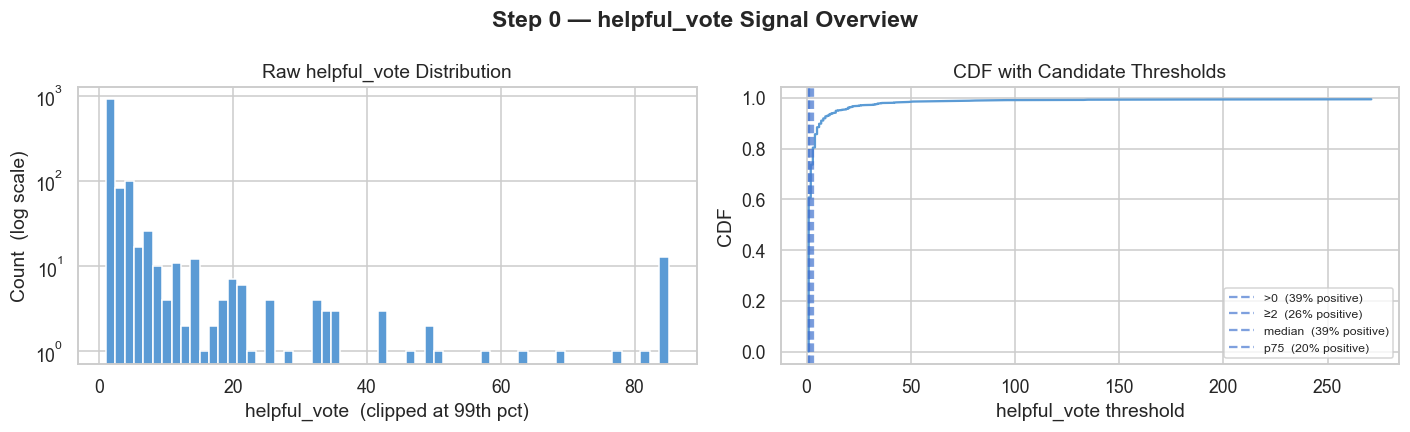

  Threshold  Positive N  Negative N Positive %     Ratio Imbalance Risk
  > 0  :EDA        1233           0     100.0% 1233.00:1           High
> 1: MEDIAN         484         749      39.3%    0.65:1            Low
   > 3: P75         242         991      19.6%    0.24:1       Moderate


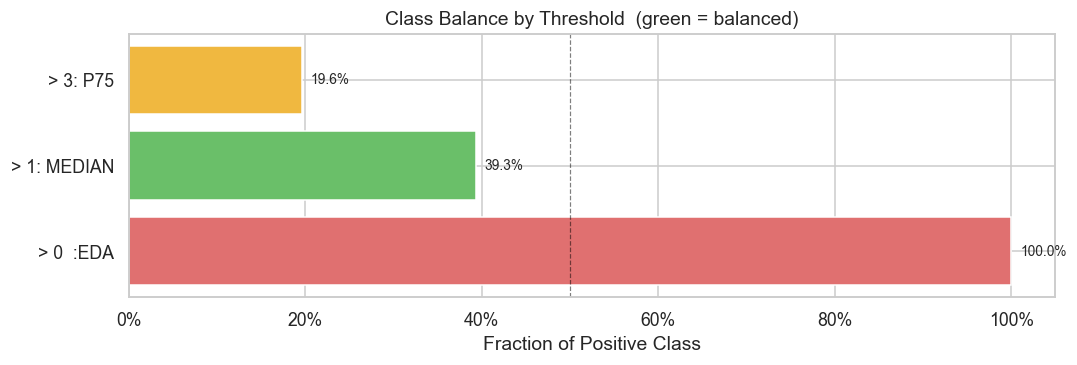

In [152]:
hv = df['helpful_vote'].clip(upper=df['helpful_vote'].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution (log y-scale to show the long tail)
axes[0].hist(hv, bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_xlabel('helpful_vote  (clipped at 99th pct)')
axes[0].set_ylabel('Count  (log scale)')
axes[0].set_title('Raw helpful_vote Distribution')

# Right: CDF — helps us read off threshold positions directly
sorted_hv = np.sort(df['helpful_vote'].values)
cdf = np.arange(1, len(sorted_hv) + 1) / len(sorted_hv)
axes[1].plot(sorted_hv[:int(0.995 * len(sorted_hv))],
             cdf[:int(0.995 * len(sorted_hv))], color='#5b9bd5')
for t, lbl in [(1, '>0'), (2, '≥2'),
               (int(df['helpful_vote'].median()), 'median'),
               (int(df['helpful_vote'].quantile(0.75)), 'p75')]:
    pct = (df['helpful_vote'] > t).mean() if t > 0 else (df['helpful_vote'] >= t).mean()
    axes[1].axvline(t, linestyle='--', alpha=0.7, label=f'{lbl}  ({pct:.0%} positive)')
axes[1].set_xlabel('helpful_vote threshold')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF with Candidate Thresholds')
axes[1].legend(fontsize=8)

plt.suptitle('Step 0 — helpful_vote Signal Overview', fontweight='bold')
plt.tight_layout(); plt.show()


# Threshold Sensitivity Analysis
median_hv = int(df['helpful_vote'].median())
p75_hv    = int(df['helpful_vote'].quantile(0.75))

thresholds = [
    ('> 0  :EDA',    df['helpful_vote'].gt(0)),
    (f'> {median_hv}: MEDIAN',  df['helpful_vote'].gt(median_hv)),
    (f'> {p75_hv}: P75',  df['helpful_vote'].gt(p75_hv)),
]

rows = []
for name, mask in thresholds:
    pos = mask.sum()
    neg = (~mask).sum()
    pct = pos / len(df)
    rows.append({'Threshold': name, 'Positive N': pos, 'Negative N': neg,
                 'Positive %': f'{pct:.1%}', 'Ratio': f'{pos/max(neg,1):.2f}:1',
                 'Imbalance Risk': 'High' if pct < 0.15 or pct > 0.85 else
                                   'Moderate' if pct < 0.25 or pct > 0.75 else 'Low'})

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

# Visualise class balance
fig, ax = plt.subplots(figsize=(10, 3.5))
names  = [r['Threshold'] for r in rows]
ratios = [float(r['Positive %'].strip('%')) / 100 for r in rows]
bars = ax.barh(names, ratios, color=['#e07070' if r > 0.80 or r < 0.15
                                     else '#f0b840' if r > 0.70 or r < 0.25
                                     else '#6abf69' for r in ratios])
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Fraction of Positive Class')
ax.set_title('Class Balance by Threshold  (green = balanced)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, r in zip(bars, ratios):
    ax.text(r + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{r:.1%}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 6.1 Create the Target Variable

- Using Median (1) as a threshold

In [153]:
# Calculate helpful threshold using median
HELPFUL_THRESHOLD = df['helpful_vote'].median()

# Create target variable
df['is_helpful'] = (df['helpful_vote'] > HELPFUL_THRESHOLD).astype('int8')

print(f"Target Variable Distribution:")
print(df['is_helpful'].value_counts().sort_index())
print(f"\nClass Proportions:")
print(df['is_helpful'].value_counts(normalize=True).sort_index())

Target Variable Distribution:
is_helpful
0    749
1    484
Name: count, dtype: int64

Class Proportions:
is_helpful
0    0.607461
1    0.392539
Name: proportion, dtype: float64


# 7. Feature Analysis

## 7.1 Helper Functions

In [154]:
def two_class_dist(feature: str, label: str = 'is_helpful', clip_pct: float = 0.99,
                   xlabel: str = None, title: str = None):
    """KDE + rug for a numeric feature split by binary target."""
    sub = df[[feature, label]].dropna()
    q   = sub[feature].quantile(clip_pct)
    sub = sub[sub[feature] <= q]
    fig, ax = plt.subplots(figsize=(9, 4))
    for val, lbl, col in [(0, 'Not Helpful', '#e07070'), (1, 'Helpful', '#5b9bd5')]:
        sns.kdeplot(sub.loc[sub[label] == val, feature], ax=ax,
                    fill=True, alpha=0.35, label=lbl, color=col)
    ax.set_xlabel(xlabel or feature)
    ax.set_title(title or f'Distribution of `{feature}` by Helpfulness')
    ax.legend()
    plt.tight_layout(); plt.show()
    # Point-biserial correlation
    r, p = stats.pointbiserialr(sub[label], sub[feature])
    print(f"  Point-biserial r = {r:+.4f}  (p = {p:.3g})")

def bar_vs_target(feature: str, label: str = 'is_helpful', title: str = None):
    """Stacked bar: proportion helpful per category."""
    sub = df[[feature, label]].dropna()
    order = sorted(sub[feature].unique())
    prop  = sub.groupby(feature)[label].mean()
    counts = sub[feature].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(prop.index.astype(str), prop.values, color='#5b9bd5', edgecolor='white')
    ax.set_ylabel('Proportion Helpful')
    ax.set_xlabel(feature)
    ax.set_title(title or f'Helpfulness Rate by `{feature}`')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for x, (cat, val) in enumerate(prop.items()):
        ax.text(x, val + 0.005, f'{counts[cat]:,}', ha='center', fontsize=8, color='#555')
    plt.tight_layout(); plt.show()

def compute_mi(features: list, label: str = 'is_helpful', n: int = 100_000) -> pd.Series:
    """Mutual information (classification) for a list of numeric features."""
    sub = df[features + [label]].dropna()
    if len(sub) > n:
        sub = sub.sample(n, random_state=RANDOM_STATE)
    X = sub[features].fillna(0)
    y = sub[label]
    mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    return pd.Series(mi, index=features).sort_values(ascending=False)

def vif_table(features: list) -> pd.DataFrame:
    """Variance Inflation Factor for a list of features."""
    sub = df[features].dropna().sample(min(50_000, len(df)), random_state=RANDOM_STATE)
    X   = sub.fillna(0)
    vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return pd.DataFrame({'Feature': features, 'VIF': vif}).sort_values('VIF', ascending=False)

print("Helpers defined: two_class_dist, bar_vs_target, compute_mi, vif_table")

Helpers defined: two_class_dist, bar_vs_target, compute_mi, vif_table


## 7.2 Analysis

### Textual Features

In [155]:
print("Descriptive stats for combined_text:")
print(df['combined_text'].describe())

Descriptive stats for combined_text:
count                                                  1233
unique                                                 1233
top       Very nice! I love my new larger screen Kindle ...
freq                                                      1
Name: combined_text, dtype: object



Estimated > 256 tokens (DistilBERT max): 21.3% of reviews → will be truncated


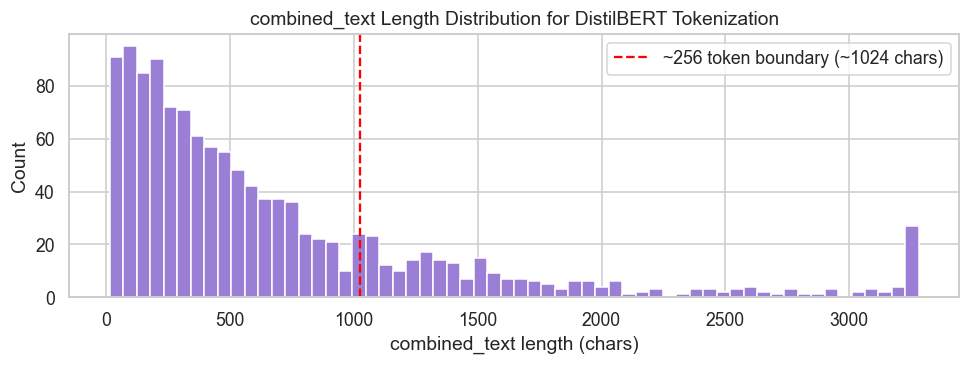


Estimated > 512 tokens (DistilBERT max): 5.9% of reviews → will be truncated


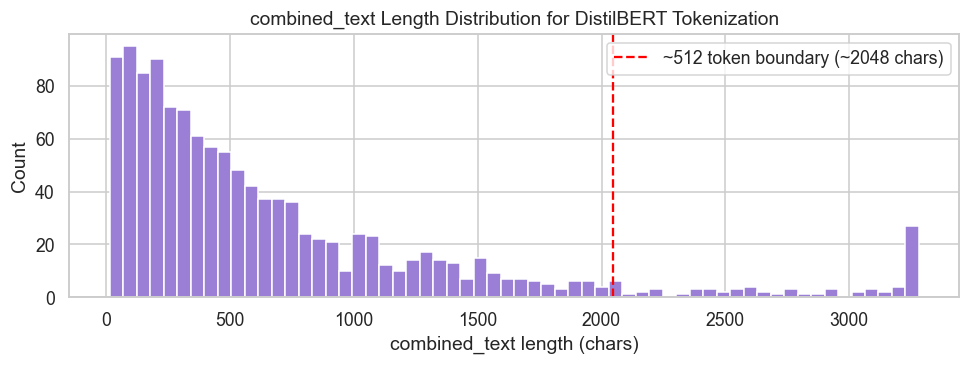

In [156]:
tokens = [256, 512]

for token in tokens:
    # Token length estimate (rough: 1 token ≈ 4 chars)
    est_tokens = (df['combined_text_length'] / 4).round(0).astype(int)
    over_limit = (est_tokens > token).mean()
    print(f"\nEstimated > {token} tokens (DistilBERT max): {over_limit:.1%} of reviews → will be truncated")

    # Length distribution
    fig, ax = plt.subplots(figsize=(9, 3.5))
    clip = df['combined_text_length'].quantile(0.98)
    ax.hist(df['combined_text_length'].clip(upper=clip), bins=60, color='#9b7fd6', edgecolor='white')
    ax.axvline(token * 4, color='red', linestyle='--', label=f'~{token} token boundary (~{token * 4} chars)')
    ax.set_xlabel('combined_text length (chars)')
    ax.set_ylabel('Count')
    ax.set_title('combined_text Length Distribution for DistilBERT Tokenization')
    ax.legend()
    plt.tight_layout(); plt.show()

In [157]:
has_text = (df['text'].notna()) & (df['text'].str.strip().ne(''))
only_title = (~has_text) & (df['title'].notna()) & (df['title'].str.strip().ne(''))

# Create comparison
comparison = pd.DataFrame({
    'Group': ['Title + Text', 'Title Only'],
    'Count': [has_text.sum(), only_title.sum()],
    'Helpful Count': [
        df.loc[has_text, 'is_helpful'].sum(),
        df.loc[only_title, 'is_helpful'].sum()
    ],
    'Helpfulness Rate': [
        df.loc[has_text, 'is_helpful'].mean(),
        df.loc[only_title, 'is_helpful'].mean()
    ]
})

print("="*70)
print("HELPFULNESS COMPARISON: Title+Text vs Title Only")
print("="*70)
print(comparison.to_string(index=False))

HELPFULNESS COMPARISON: Title+Text vs Title Only
       Group  Count  Helpful Count  Helpfulness Rate
Title + Text   1233            484          0.392539
  Title Only      0              0               NaN


Reviews with title but no text:
title_exists_only
0    1233
Name: count, dtype: int64

Proportion: 0.000%

HELPFULNESS ANALYSIS: Title Exists But Text Does Not


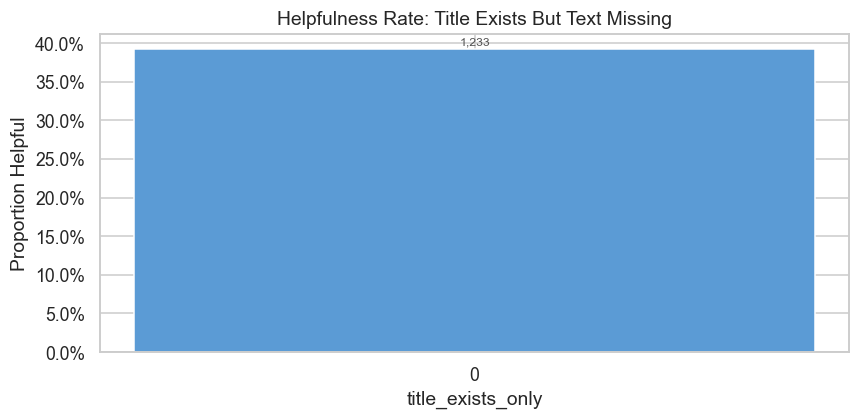


Point-biserial correlation: r = +nan  (p = nan)

is_helpful         Not Helpful  Helpful  Total
title_exists_only                             
Text Present               749      484   1233
Total                      749      484   1233


In [158]:
print("Reviews with title but no text:")
print(df['title_exists_only'].value_counts())
print(f"\nProportion: {df['title_exists_only'].mean():.3%}")

# Analyze relationship with is_helpful
print("\n" + "="*60)
print("HELPFULNESS ANALYSIS: Title Exists But Text Does Not")
print("="*60)

bar_vs_target('title_exists_only', 
              title='Helpfulness Rate: Title Exists But Text Missing')

# Correlation
sub = df[['is_helpful', 'title_exists_only']].dropna()
r, p = stats.pointbiserialr(sub['is_helpful'], sub['title_exists_only'])
print(f"\nPoint-biserial correlation: r = {r:+.4f}  (p = {p:.3g})")

# Cross-tabulation
print("\n" + "="*60)
ct = pd.crosstab(df['title_exists_only'], df['is_helpful'], margins=True)
ct = ct.rename(index={0: 'Text Present', 1: 'Text Missing', 'All': 'Total'},
               columns={0: 'Not Helpful', 1: 'Helpful', 'All': 'Total'})
print(ct)

### Lexical Features

Descriptive stats for review_length:
count    1233.0
mean      709.6
std       871.0
min         7.0
25%       197.0
50%       438.0
75%       882.0
max      9123.0
Name: review_length, dtype: float64


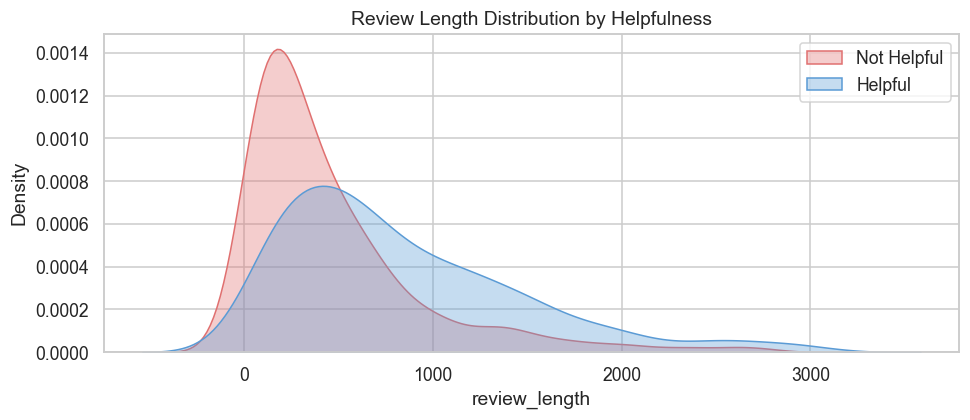

  Point-biserial r = +0.3145  (p = 7.08e-29)
  Median length — Not Helpful: 299 chars
  Median length — Helpful: 720 chars


In [159]:
print("Descriptive stats for review_length:")
print(df['review_length'].describe().round(1))

two_class_dist('review_length', clip_pct=0.97,
               title='Review Length Distribution by Helpfulness')

# Median length by helpfulness class
for cls, lbl in [(0, 'Not Helpful'), (1, 'Helpful')]:
    med = df.loc[df['is_helpful'] == cls, 'review_length'].median()
    print(f"  Median length — {lbl}: {med:.0f} chars")

  r(word_count, review_length) = 0.9983
  r(chars_per_word, review_length) = -0.1219


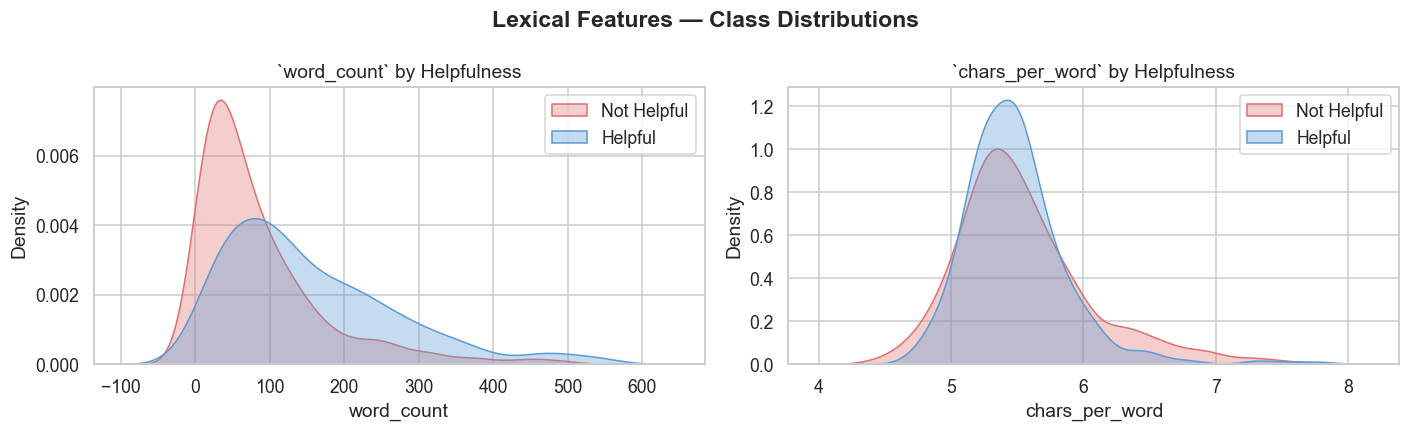

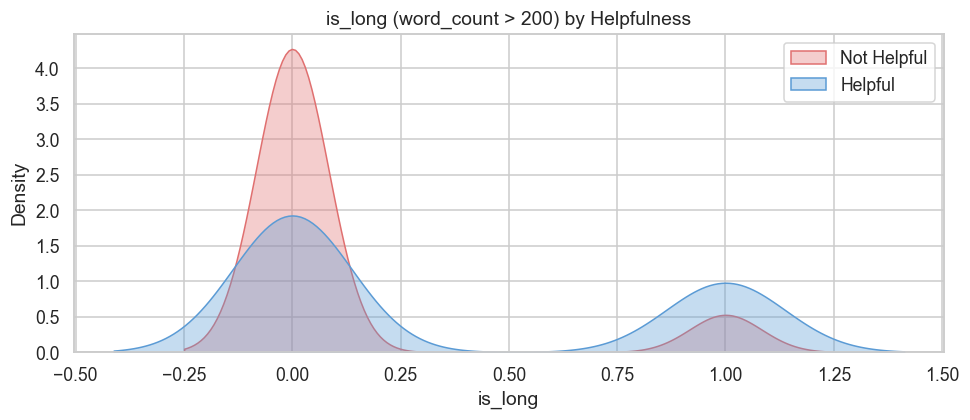

  Point-biserial r = +0.2782  (p = 2.41e-23)


In [160]:
# Correlation: word_count vs review_length
for f1, f2 in [('word_count', 'review_length'), ('chars_per_word', 'review_length')]:
    if f1 in df.columns and f2 in df.columns:
        r = df[[f1, f2]].corr().iloc[0, 1]
        print(f"  r({f1}, {f2}) = {r:.4f}")

# Distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat, clip in zip(axes, ['word_count', 'chars_per_word'], [0.97, 0.99]):
    if feat not in df.columns:
        continue
    sub = df[[feat, 'is_helpful']].dropna()
    q   = sub[feat].quantile(clip)
    sub = sub[sub[feat] <= q]
    for val, lbl, col in [(0, 'Not Helpful', '#e07070'), (1, 'Helpful', '#5b9bd5')]:
        sns.kdeplot(sub.loc[sub['is_helpful'] == val, feat],
                    ax=ax, fill=True, alpha=0.35, label=lbl, color=col)
    ax.set_title(f'`{feat}` by Helpfulness')
    ax.legend()
plt.suptitle('Lexical Features — Class Distributions', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('is_long', title='is_long (word_count > 200) by Helpfulness')

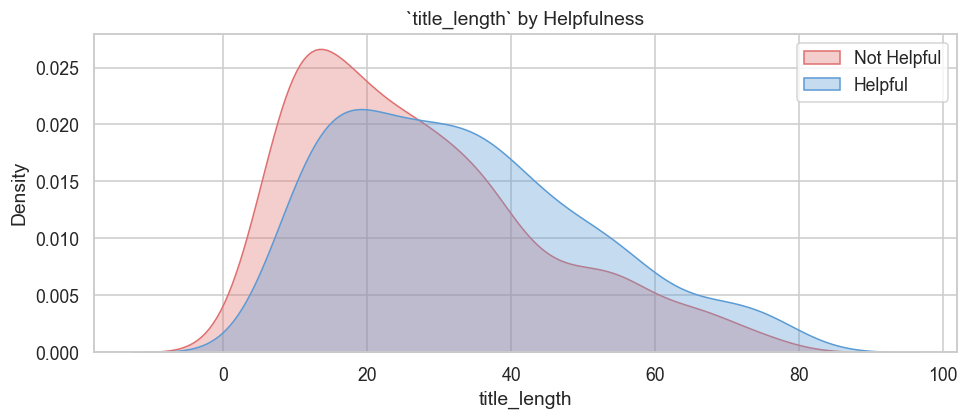

  Point-biserial r = +0.1712  (p = 2.55e-09)


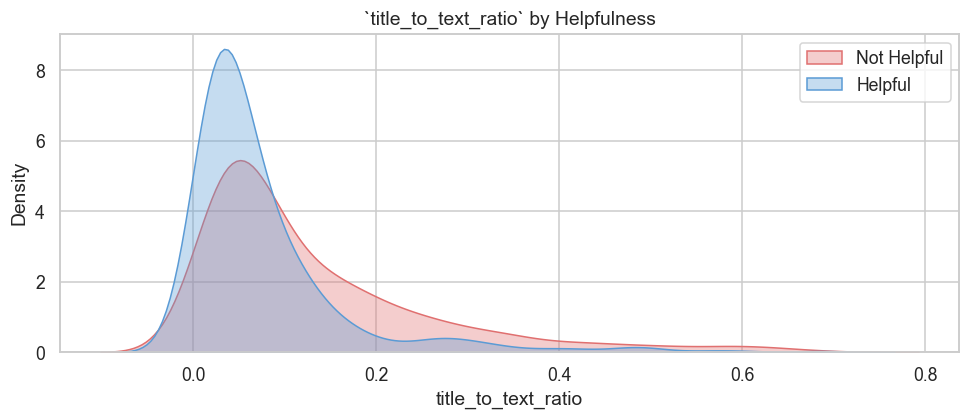

  Point-biserial r = -0.2245  (p = 3.96e-15)

  r(text_length, review_length) = 0.9997  ← redundant


In [161]:
for feat in ['title_length', 'title_to_text_ratio']:
    two_class_dist(feat, clip_pct=0.97, title=f'`{feat}` by Helpfulness')

# Correlation with review_length
if 'text_length' in df.columns:
    r = df[['text_length', 'review_length']].corr().iloc[0, 1]
    print(f"\n  r(text_length, review_length) = {r:.4f}  "
            f"← {'redundant' if abs(r) > 0.95 else 'non-redundant'}")

Descriptive stats for exclamation marks:
count    1233.0
mean        1.0
std         2.3
min         0.0
25%         0.0
50%         0.0
75%         1.0
max        31.0
Name: exclamation_mark, dtype: float64


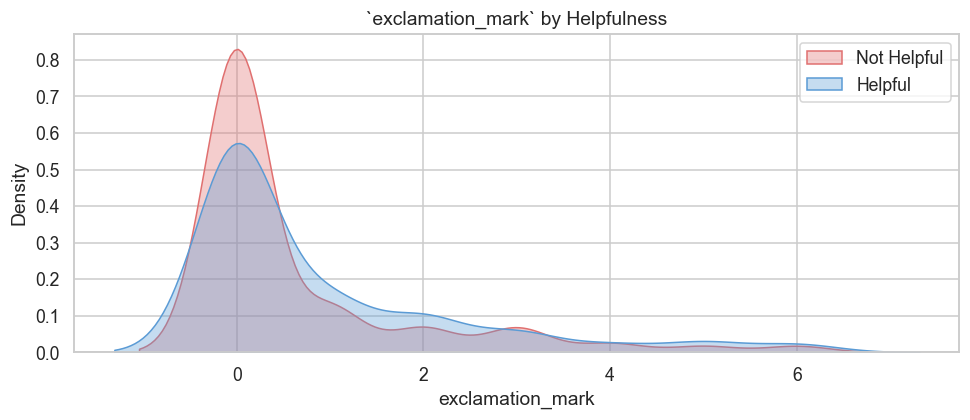

  Point-biserial r = +0.0911  (p = 0.00157)


In [162]:
print("Descriptive stats for exclamation marks:")
print(df['exclamation_mark'].describe().round(1))

two_class_dist('exclamation_mark', clip_pct=0.97, title=f'`exclamation_mark` by Helpfulness')

Descriptive stats for question marks:
count    1233.0
mean        0.2
std         0.8
min         0.0
25%         0.0
50%         0.0
75%         0.0
max        18.0
Name: question_mark, dtype: float64


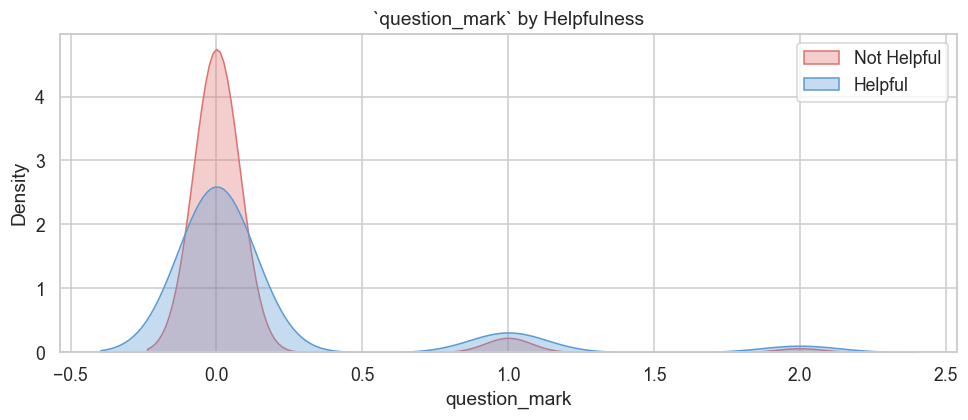

  Point-biserial r = +0.1326  (p = 3.36e-06)


In [163]:
print("Descriptive stats for question marks:")
print(df['question_mark'].describe().round(1))

two_class_dist('question_mark', clip_pct=0.97, title=f'`question_mark` by Helpfulness')

### Image and Media Features

Descriptive stats for image_count:
count    1233.000000
mean        0.158151
std         0.775100
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        11.000000
Name: image_count, dtype: float64


Descriptive stats for has_image:
count    1233.000000
mean        0.065693
std         0.247846
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: has_image, dtype: float64

r(image_count, has_image) = 0.7698	 ← high → has_image is redundant


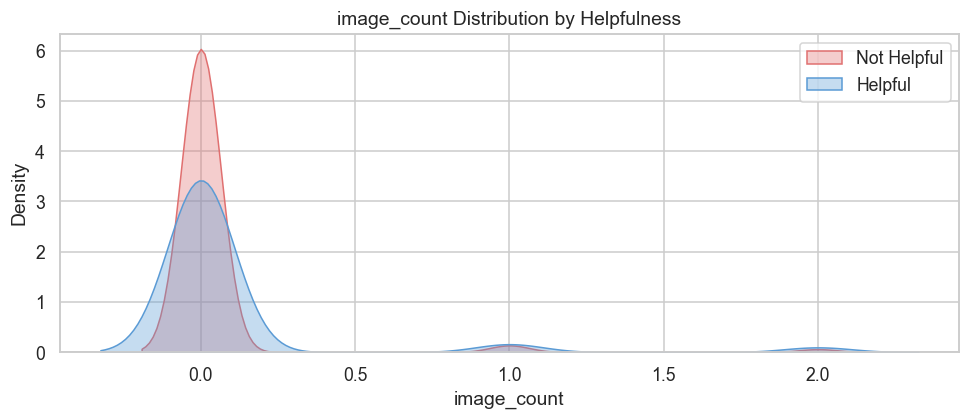

  Point-biserial r = +0.0884  (p = 0.00212)


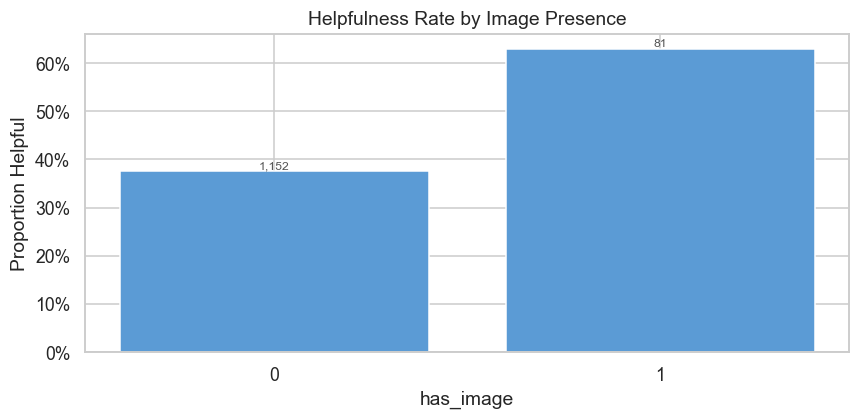

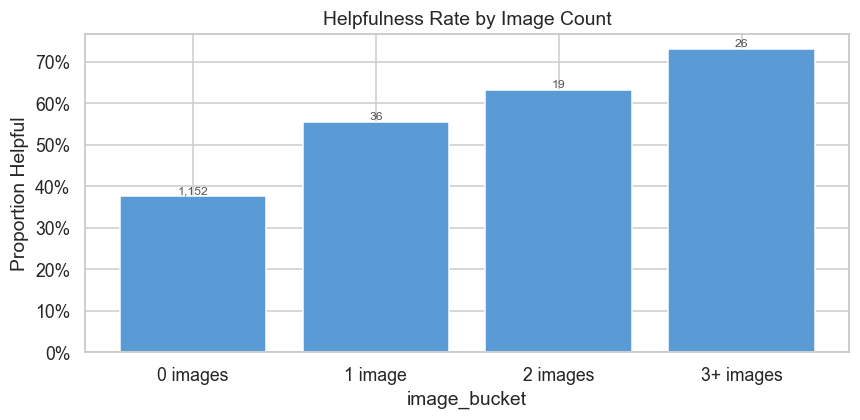

In [164]:
IMAGE_FEATURES = ['image_count', 'has_image']

print("Descriptive stats for image_count:")
print(df['image_count'].describe())

print("\n\nDescriptive stats for has_image:")
print(df['has_image'].describe())

# Correlation between image_count and has_image
r_img = df[['image_count', 'has_image']].corr().iloc[0, 1]
print(f"\nr(image_count, has_image) = {r_img:.4f}\t ← high → has_image is redundant")

# Visualize image_count distribution by helpfulness
two_class_dist('image_count', 
            clip_pct=0.97,
            title='image_count Distribution by Helpfulness')

# Visualize has_image by helpfulness (binary feature)
bar_vs_target('has_image', title='Helpfulness Rate by Image Presence')

# Helpfulness rate: 0, 1, 2, 3+ images
bar_vs_target('image_bucket', title='Helpfulness Rate by Image Count')


### Temporal Feature

In [165]:
# days_since_first_review: how long has this review been live?
if 'days_since_first_review' not in df.columns:
    ref_date = df['review_date'].max()   # NOTE: use train-set max in production!
    df['days_since_first_review'] = (ref_date - df['review_date']).dt.days
    print(f"Computed days_since_first_review  (ref = {ref_date.date()})")
    print("WARNING: ref_date must be computed from TRAIN set only in production.")

print("\n=== year distribution ===")
print(df['year'].value_counts().sort_index().head(10))


=== year distribution ===
year
2007      1
2008      6
2009      7
2010      5
2011     20
2012     40
2013     38
2014     63
2015     87
2016    149
Name: count, dtype: int64


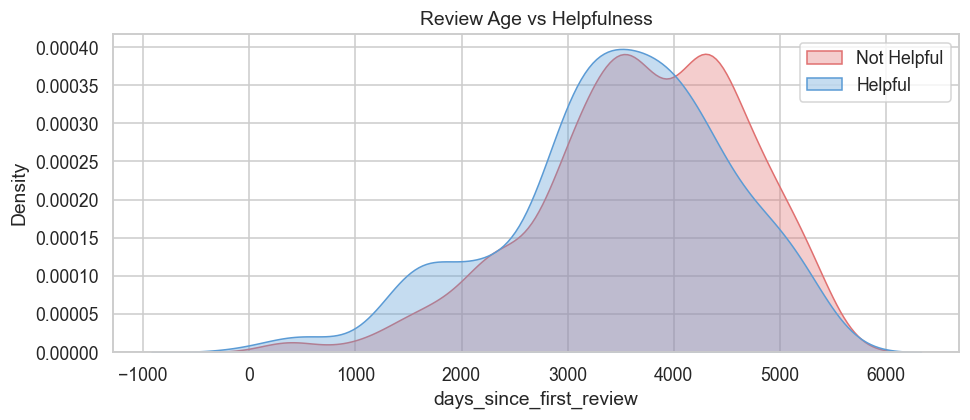

  Point-biserial r = -0.1168  (p = 5.13e-05)


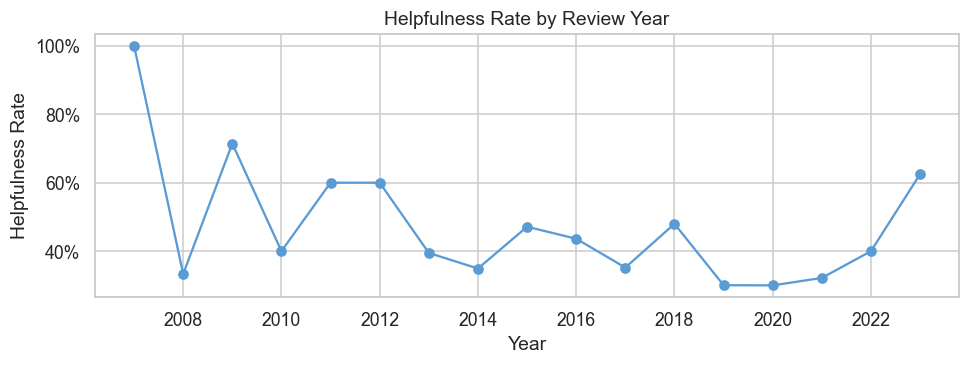

In [166]:
two_class_dist('days_since_first_review', clip_pct=0.97,
                title='Review Age vs Helpfulness')

# Year-level trend
if 'year' in df.columns:
    yr_help = df.groupby('year')['is_helpful'].mean()
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(yr_help.index, yr_help.values, marker='o', color='#5b9bd5')
    ax.set_xlabel('Year')
    ax.set_ylabel('Helpfulness Rate')
    ax.set_title('Helpfulness Rate by Review Year')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.tight_layout(); plt.show()

### Purchase & Product Features

Descriptive stats for product_popularity:
count    1233.0
mean       11.2
std         9.5
min         5.0
25%         5.0
50%         6.0
75%        11.0
max        36.0
Name: product_popularity, dtype: float64
Descriptive stats for log_popularity:
count    1233.0
mean        2.3
std         0.6
min         1.8
25%         1.8
50%         1.9
75%         2.5
max         3.6
Name: log_popularity, dtype: float64


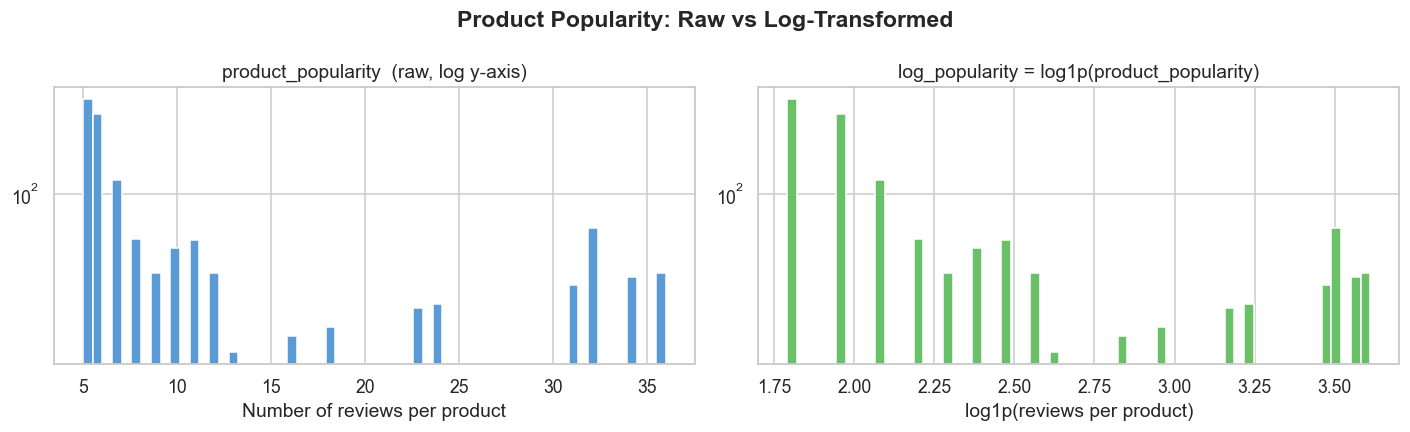

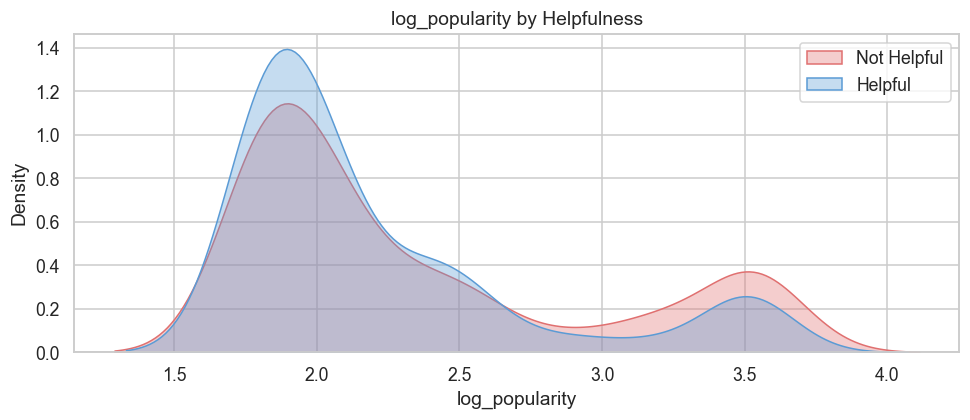

  Point-biserial r = -0.1136  (p = 6.4e-05)

  Spearman r — product_popularity (raw): -0.0903
  Spearman r — log_popularity:           -0.0903


In [167]:
print("Descriptive stats for product_popularity:")
print(df['product_popularity'].describe().round(1))

print("Descriptive stats for log_popularity:")
print(df['log_popularity'].describe().round(1))


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution — log y to show the power law
axes[0].hist(df['product_popularity'].clip(upper=df['product_popularity'].quantile(0.99)),
                bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_title('product_popularity  (raw, log y-axis)')
axes[0].set_xlabel('Number of reviews per product')

# Log-transformed
axes[1].hist(df['log_popularity'], bins=60, color='#6abf69', edgecolor='white', log=True)
axes[1].set_title('log_popularity = log1p(product_popularity)')
axes[1].set_xlabel('log1p(reviews per product)')

plt.suptitle('Product Popularity: Raw vs Log-Transformed', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('log_popularity', title='log_popularity by Helpfulness')

r_raw = stats.spearmanr(df['product_popularity'].dropna(),
                            df['is_helpful'][:len(df['product_popularity'].dropna())]).correlation
r_log = stats.spearmanr(df['log_popularity'].dropna(),
                            df['is_helpful'][:len(df['log_popularity'].dropna())]).correlation
print(f"\n  Spearman r — product_popularity (raw): {r_raw:+.4f}")
print(f"  Spearman r — log_popularity:           {r_log:+.4f}")

### Rating

rating
1.0    195
2.0     67
3.0     89
4.0    193
5.0    689
Name: count, dtype: int64

Missing: 0


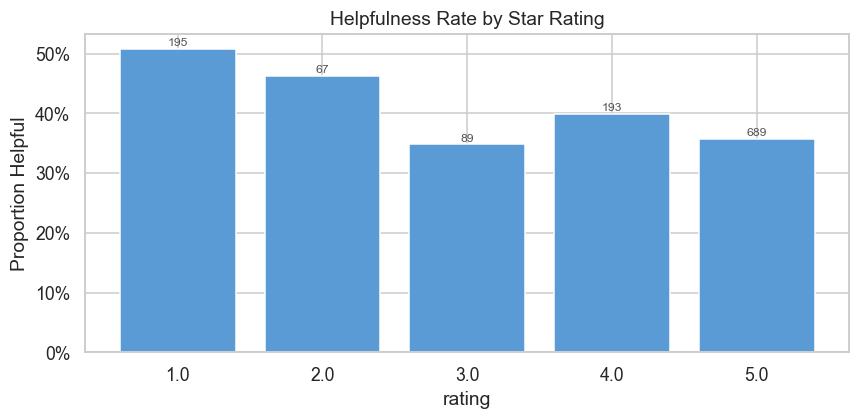

  rating                 point-biserial r = -0.1074  p = 0.000157
  rating_extremity       point-biserial r = +0.0053  p = 0.854


In [168]:
print(df['rating'].value_counts().sort_index())
print(f"\nMissing: {df['rating'].isna().sum()}")

bar_vs_target('rating', title='Helpfulness Rate by Star Rating')

# Correlations
for feat in ['rating', 'rating_extremity']:
    if feat in df.columns:
        sub = df[['is_helpful', feat]].dropna()

        r, p = stats.pointbiserialr(
            sub['is_helpful'],
            sub[feat]
        )
        print(f"  {feat:<22} point-biserial r = {r:+.4f}  p = {p:.3g}")

### Verified Purchase

Descriptive stats for log_popularity:
count    1233.0
mean        2.3
std         0.6
min         1.8
25%         1.8
50%         1.9
75%         2.5
max         3.6
Name: log_popularity, dtype: float64


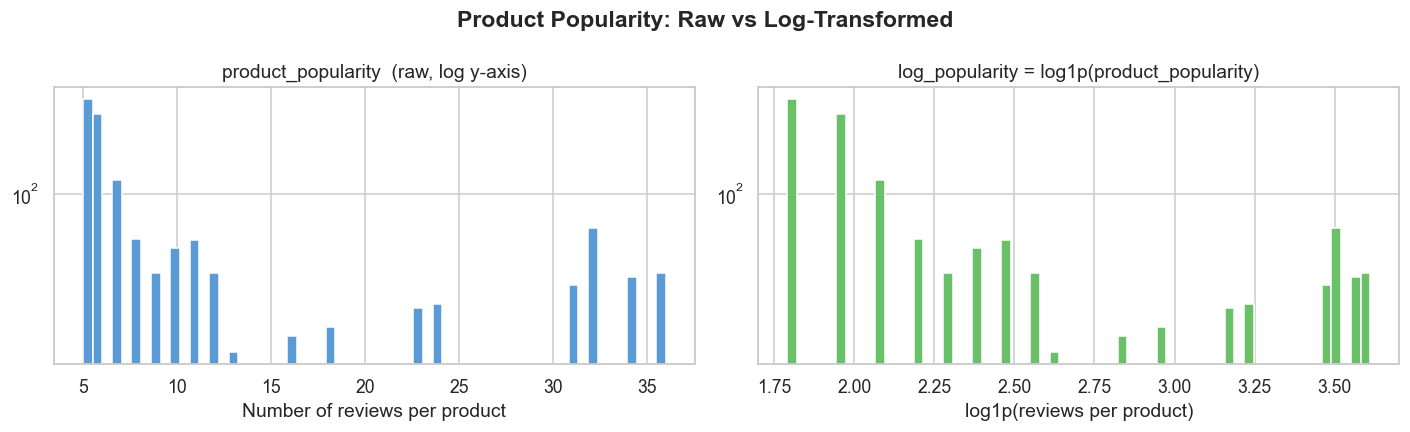

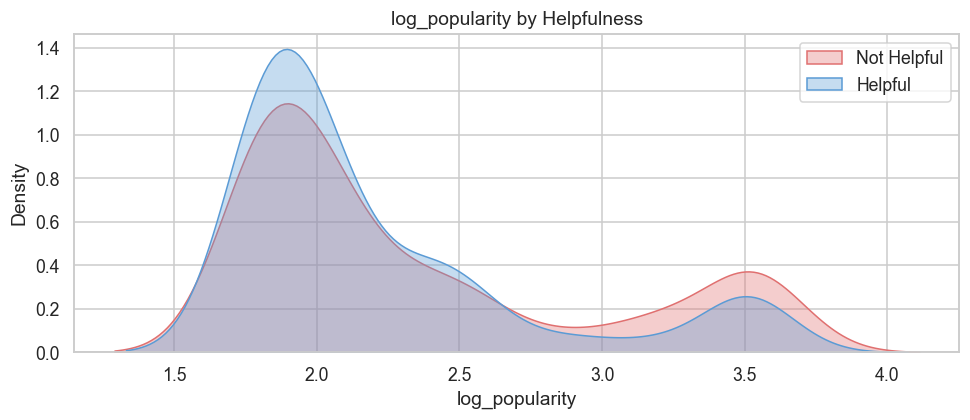

  Point-biserial r = -0.1136  (p = 6.4e-05)

  Spearman r — product_popularity (raw): -0.0903
  Spearman r — log_popularity:           -0.0903


In [169]:
print("Descriptive stats for log_popularity:")
print(df['log_popularity'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution — log y to show the power law
axes[0].hist(df['product_popularity'].clip(upper=df['product_popularity'].quantile(0.99)),
                bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_title('product_popularity  (raw, log y-axis)')
axes[0].set_xlabel('Number of reviews per product')

# Log-transformed
axes[1].hist(df['log_popularity'], bins=60, color='#6abf69', edgecolor='white', log=True)
axes[1].set_title('log_popularity = log1p(product_popularity)')
axes[1].set_xlabel('log1p(reviews per product)')

plt.suptitle('Product Popularity: Raw vs Log-Transformed', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('log_popularity', title='log_popularity by Helpfulness')

r_raw = stats.spearmanr(df['product_popularity'].dropna(),
                            df['is_helpful'][:len(df['product_popularity'].dropna())]).correlation
r_log = stats.spearmanr(df['log_popularity'].dropna(),
                            df['is_helpful'][:len(df['log_popularity'].dropna())]).correlation
print(f"\n  Spearman r — product_popularity (raw): {r_raw:+.4f}")
print(f"  Spearman r — log_popularity:           {r_log:+.4f}")

### Overall 

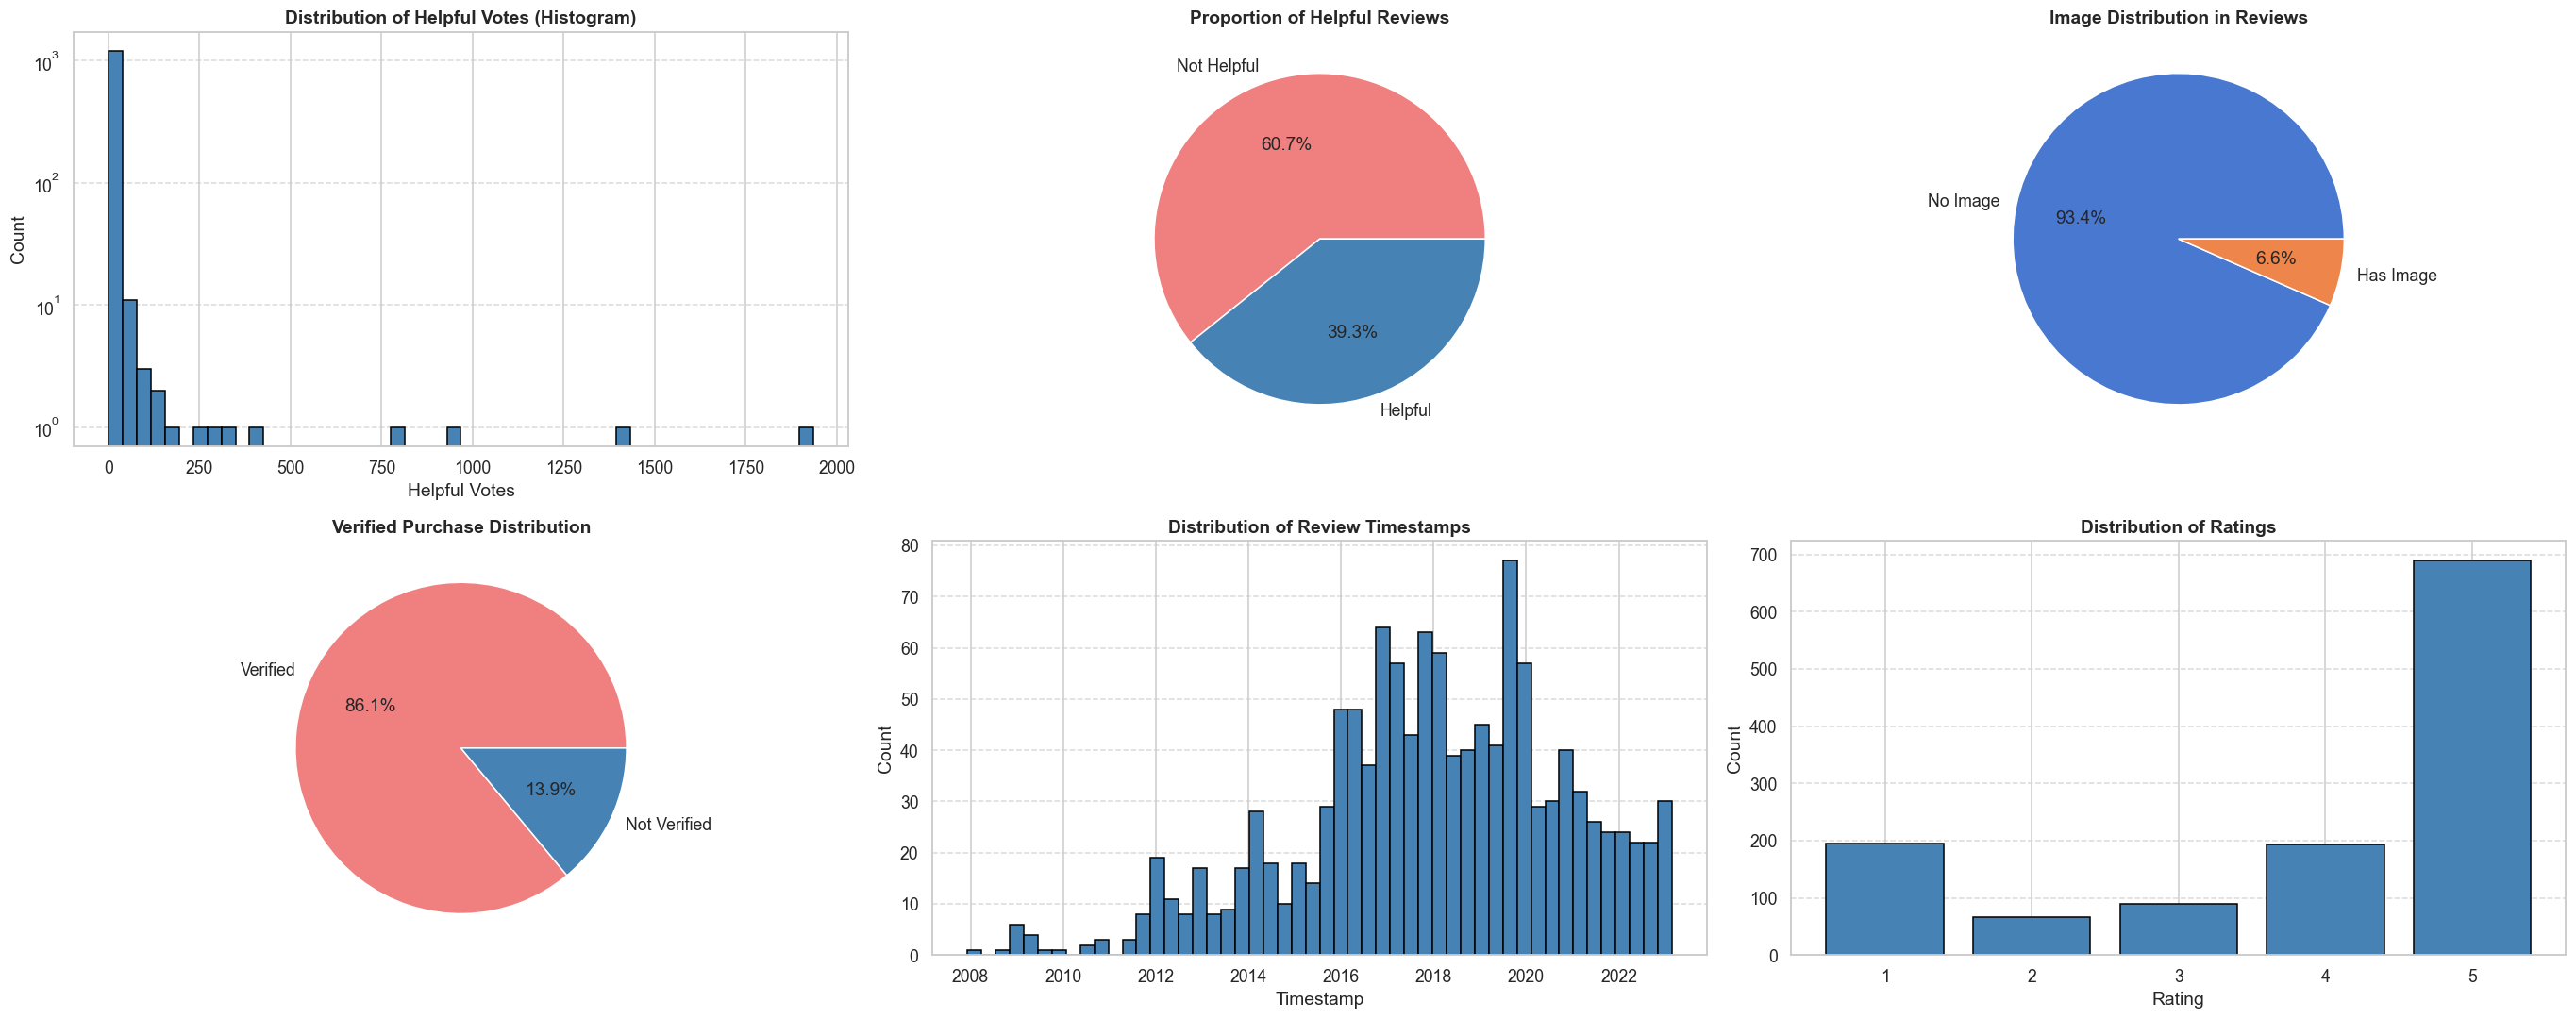


⭐ Rating Distribution:
  1.0:  15.8% █████
  2.0:   5.4% █
  3.0:   7.2% ██
  4.0:  15.7% █████
  5.0:  55.9% ██████████████████


<Figure size 704x528 with 0 Axes>

In [170]:
# Section 4: All Visualizations Combined into Subplots
fig, axes = plt.subplots(2, 3, figsize=(25, 10))
axes = axes.flatten()


# 1. Helpful Votes Histogram
axes[0].hist(df['helpful_vote'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Helpful Votes (Histogram)', fontweight='bold')
axes[0].set_xlabel('Helpful Votes')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Helpful Votes Pie Chart
is_helpful_review = df['is_helpful']
counts = is_helpful_review.value_counts(sort=False).sort_index()
axes[1].pie(counts, labels=['Not Helpful', 'Helpful'], autopct='%1.1f%%', 
            colors=['lightcoral', 'steelblue'])
axes[1].set_title('Proportion of Helpful Reviews', fontweight='bold')

# 3. Image Distribution
has_image = df['has_image'].value_counts()
axes[2].pie(has_image.values, 
            labels=['Has Image' if i else 'No Image' for i in has_image.index],
            autopct='%1.1f%%')
axes[2].set_title('Image Distribution in Reviews', fontweight='bold')

# 4. Verified Purchase Distribution
verified = df['is_verified'].value_counts()
axes[3].pie(verified.values, 
            labels=['Verified' if v else 'Not Verified' for v in verified.index],
            autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[3].set_title('Verified Purchase Distribution', fontweight='bold')

# 5. Timestamp Distribution
axes[4].hist(df['timestamp'], bins=50, color='steelblue', edgecolor='black')
axes[4].set_title('Distribution of Review Timestamps', fontweight='bold')
axes[4].set_xlabel('Timestamp')
axes[4].set_ylabel('Count')
axes[4].grid(axis='y', linestyle='--', alpha=0.7)

# 6. Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[5].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[5].set_title('Distribution of Ratings', fontweight='bold')
axes[5].set_xlabel('Rating')
axes[5].set_ylabel('Count')
axes[5].set_xticks(rating_counts.index)
axes[5].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print statistics after the plot
print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

plt.tight_layout()
plt.show()

## 7.3 Statistical Analysis

In [171]:
NUMERIC_COLS = df.select_dtypes(include='number').columns

if 'helpful_vote' in NUMERIC_COLS:
    NUMERIC_COLS = NUMERIC_COLS.drop('helpful_vote')

print(f"Numeric features available for MI and VIF: {NUMERIC_COLS}")

Numeric features available for MI and VIF: Index(['rating', 'review_length', 'combined_text_length', 'title_length',
       'text_length', 'title_to_text_ratio', 'exclamation_mark',
       'question_mark', 'word_count', 'chars_per_word', 'is_long',
       'title_exists_only', 'image_count', 'has_image', 'day_of_week',
       'is_weekend', 'year', 'days_since_first_review', 'is_verified',
       'product_popularity', 'log_popularity', 'rating_extremity',
       'is_helpful'],
      dtype='str')


CORRELATION ANALYSIS


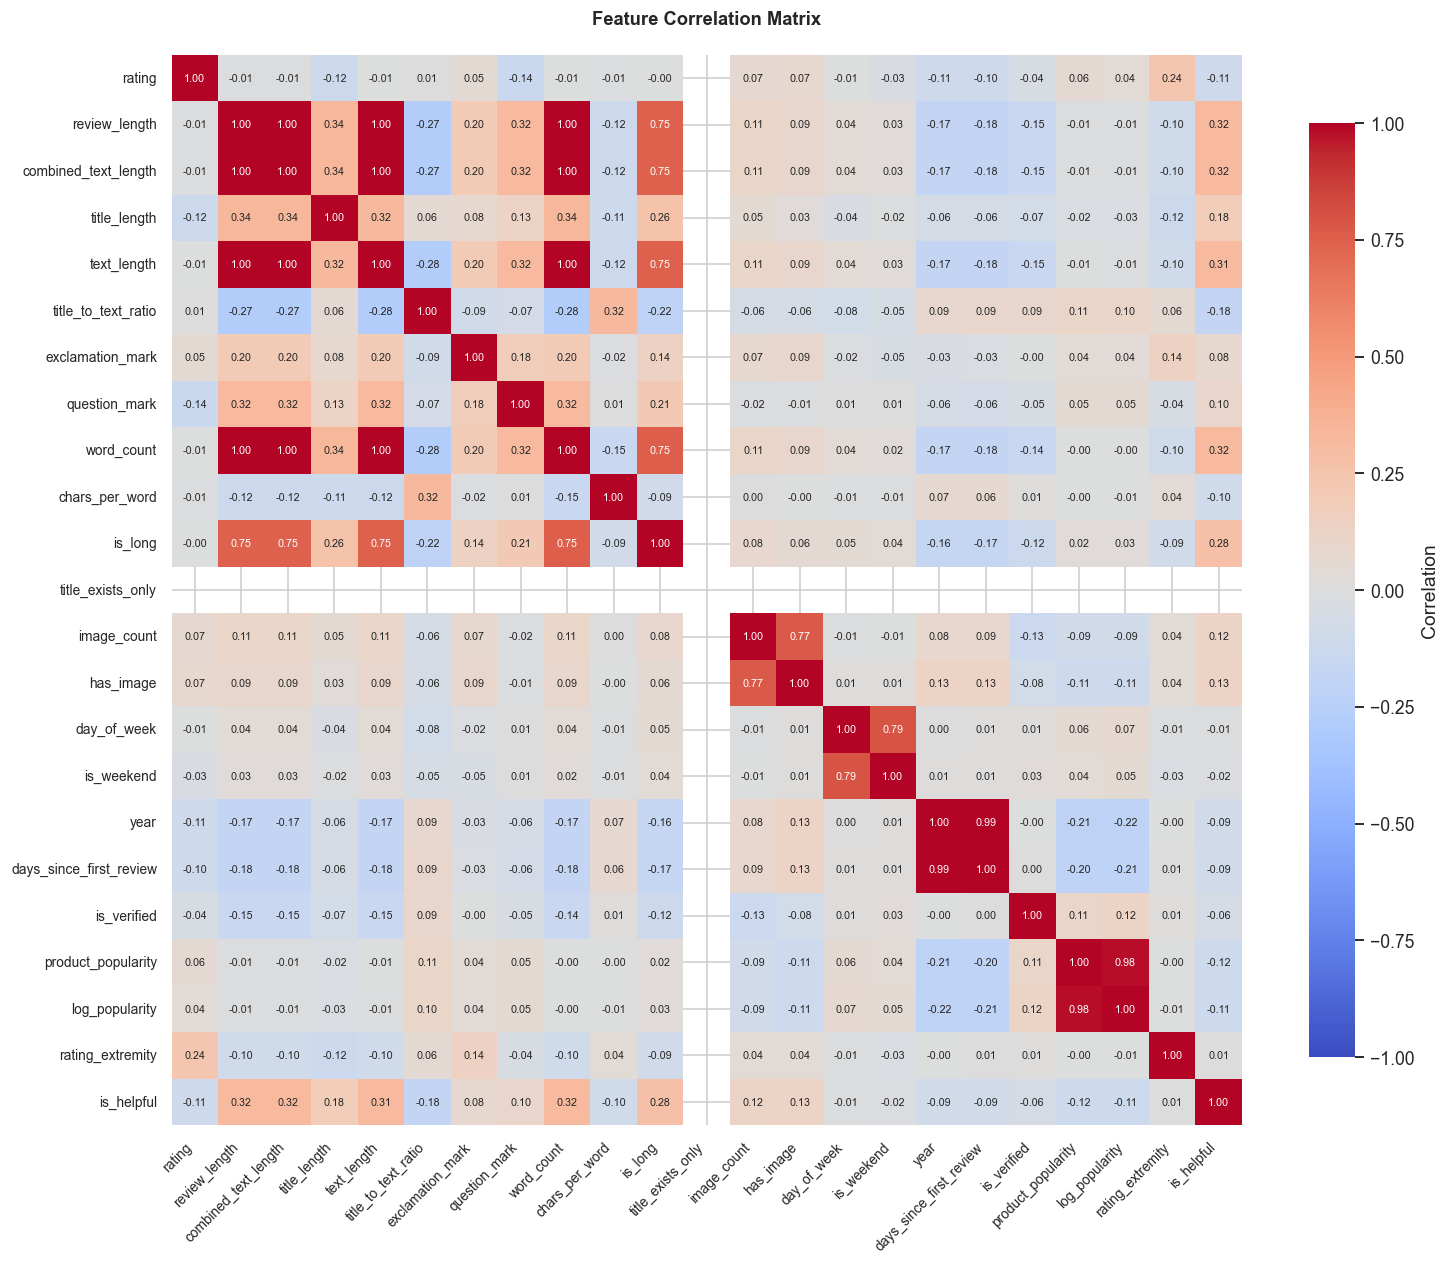


Key Correlations with Helpful Votes:
  word_count               :  0.3193
  review_length            :  0.3158
  combined_text_length     :  0.3158
  text_length              :  0.3140
  is_long                  :  0.2782
  title_length             :  0.1800
  has_image                :  0.1287
  image_count              :  0.1189
  question_mark            :  0.0990
  exclamation_mark         :  0.0777
  rating_extremity         :  0.0053
  day_of_week              : -0.0133
  is_weekend               : -0.0158
  is_verified              : -0.0598
  days_since_first_review  : -0.0932
  year                     : -0.0936
  chars_per_word           : -0.0965
  rating                   : -0.1074
  log_popularity           : -0.1136
  product_popularity       : -0.1156
  title_to_text_ratio      : -0.1755
  title_exists_only        :     nan


Helpful Votes by Rating:
        Count  Mean  Median
rating                     
1.0       195  0.51     1.0
2.0        67  0.46     0.0
3.0      

In [172]:
# CORRELATION ANALYSIS
print("CORRELATION ANALYSIS")
print("=" * 70)

# Numeric correlation matrix
corr_matrix = df[NUMERIC_COLS].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7}, 
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

# Key insights
print("\nKey Correlations with Helpful Votes:")
helpful_corr = corr_matrix['is_helpful'].sort_values(ascending=False)
for col, val in helpful_corr.items():
    if col != 'is_helpful':
        print(f"  {col:25s}: {val:7.4f}")

# Helpful votes by rating
print(f"\n\nHelpful Votes by Rating:")
helpful_by_rating = df.groupby('rating')['is_helpful'].agg(['count', 'mean', 'median'])
helpful_by_rating.columns = ['Count', 'Mean', 'Median']
print(helpful_by_rating.round(2))

# Helpful votes by verified purchase
print(f"\n\nHelpful Votes by Verified Purchase:")
helpful_verified = df.groupby('is_verified')['is_helpful'].agg(['count', 'mean', 'median'])
helpful_verified.index = ['Not Verified', 'Verified']
helpful_verified.columns = ['Count', 'Mean', 'Median']
print(helpful_verified.round(2))

In [173]:
# Subset + drop missing target
sub = df[NUMERIC_COLS].copy()
sub = sub.dropna(subset=['is_helpful'])
print("Number of records dropped due to missing target:", df.shape[0] - sub.shape[0])

sub_sample = sub.sample(
    n=min(500_000, len(sub)),
    random_state=42
)
print("Number of records used for MI and VIF calculations:", sub_sample.shape[0])

Number of records dropped due to missing target: 0
Number of records used for MI and VIF calculations: 1233


=== Statistical Evidence — All Numeric Features ===

                Feature  MI_Score  Spearman_r   VIF  Significant  High_VIF
            text_length    0.0954      0.3751   inf         True      True
             word_count    0.0915      0.3736 387.5         True      True
   combined_text_length    0.0693      0.3753   inf         True      True
          review_length    0.0659      0.3753   inf         True      True
         log_popularity    0.0362     -0.0903  23.8         True      True
                   year    0.0330     -0.0913  89.5         True      True
                is_long    0.0321      0.2782   2.4         True     False
         chars_per_word    0.0296     -0.0442   1.5        False     False
     product_popularity    0.0275     -0.0903  23.7         True      True
    title_to_text_ratio    0.0266     -0.2901   1.3         True     False
             is_weekend    0.0205     -0.0158   2.7        False     False
              has_image    0.0201      0.1287  

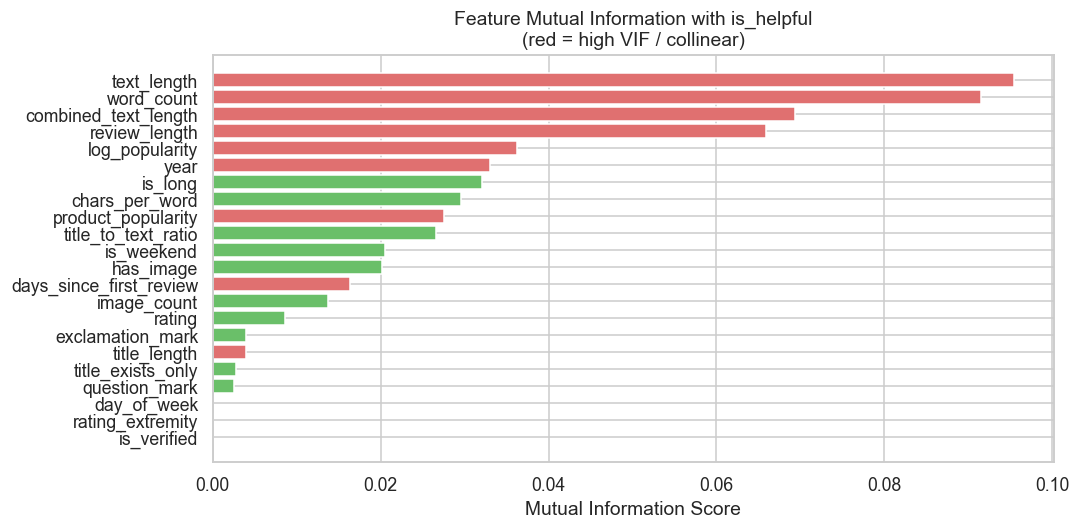

In [174]:
# Mutual Information (classification) — non-parametric, captures non-linear relationships
mi_scores = mutual_info_classif(
    sub_sample[NUMERIC_COLS.drop('is_helpful')],
    sub_sample['is_helpful'],
    random_state=42
)

# ── Spearman Correlation ──
sp_results = []
for feat in NUMERIC_COLS.drop('is_helpful'):
    r, p = stats.spearmanr(sub_sample[feat], sub_sample['is_helpful'])
    sp_results.append((feat, r, p))

# ── VIF (robust) ──
vif_sub = sub_sample[NUMERIC_COLS.drop('is_helpful')].copy()

# Drop zero-variance AFTER cleaning
vif_sub = vif_sub.loc[:, vif_sub.std() > 0]

# Final safety: ensure pure float matrix
vif_sub = vif_sub.astype(float)

vif_vals = [
    variance_inflation_factor(vif_sub.values, i)
    for i in range(vif_sub.shape[1])
]

vif_dict = dict(zip(vif_sub.columns, vif_vals))

# ── Assemble Evidence Table ──
evidence = pd.DataFrame({
    'Feature': NUMERIC_COLS.drop('is_helpful'),
    'MI_Score': mi_scores.round(4),
    'Spearman_r': [r for _, r, _ in sp_results],
    'Spearman_p': [p for _, _, p in sp_results],
    'VIF': [vif_dict.get(f, np.nan) for f in NUMERIC_COLS.drop('is_helpful')],
}).sort_values('MI_Score', ascending=False)

# Formatting
evidence['Spearman_r']  = evidence['Spearman_r'].round(4)
evidence['VIF']         = evidence['VIF'].round(1)
evidence['Significant'] = evidence['Spearman_p'] < 0.01
evidence['High_VIF']    = evidence['VIF'] > 10

print("=== Statistical Evidence — All Numeric Features ===\n")
print(
    evidence[['Feature', 'MI_Score', 'Spearman_r', 'VIF',
              'Significant', 'High_VIF']]
    .to_string(index=False)
)

# ── Plot MI Scores ──
fig, ax = plt.subplots(figsize=(10, 5))

sorted_ev = evidence.sort_values('MI_Score')

colors = [
    '#e07070' if v > 10 else '#6abf69'
    for v in sorted_ev['VIF']
]

ax.barh(
    sorted_ev['Feature'],
    sorted_ev['MI_Score'],
    color=colors,
    edgecolor='white'
)

ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Mutual Information with is_helpful\n(red = high VIF / collinear)')

plt.tight_layout()
plt.show()

## 7.4 Final Feature List

In [175]:
FINAL_FEATURES = [
    "rating",
    "review_length", 
    "chars_per_word", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
    "images",
    "combined_text",
    "is_helpful", # target variable
    "helpful_vote", # for sentiment analysis
    "parent_asin", # for sentiment analysis
]

for feat in FINAL_FEATURES:
    if feat not in df.columns:
        print(f"Warning: {feat} not found in DataFrame — skipping.")
    else:
        print(f"✓ Retaining feature: {feat}")

df = df[FINAL_FEATURES].copy()

✓ Retaining feature: rating
✓ Retaining feature: review_length
✓ Retaining feature: chars_per_word
✓ Retaining feature: image_bucket
✓ Retaining feature: days_since_first_review
✓ Retaining feature: is_verified
✓ Retaining feature: log_popularity
✓ Retaining feature: rating_extremity
✓ Retaining feature: question_mark
✓ Retaining feature: exclamation_mark
✓ Retaining feature: title_length
✓ Retaining feature: title_to_text_ratio
✓ Retaining feature: images
✓ Retaining feature: combined_text
✓ Retaining feature: is_helpful
✓ Retaining feature: helpful_vote
✓ Retaining feature: parent_asin


Check if any value is empty

In [176]:
print("Shape of DataFrame:", df.shape)

missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

Shape of DataFrame: (1233, 17)
 No missing detected!


In [177]:
print("Dataset preview:")
df.head(2)

Dataset preview:


,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,images,combined_text,is_helpful,helpful_vote,parent_asin
70,5.0,93,5.5000,0 images,2916,1,1.945910,2.0,0,2,45,0.937500,[],Very nice! I love my new larger screen Kindle ...,1,2,B00VKIY9RG
226,1.0,76,5.8571,0 images,4948,1,2.079442,2.0,0,5,31,0.688889,[],NO GOOD! DONT WASTE YOUR MONEY! [SEP] Not good...,0,1,B09Q5BNT76


# 8. Clustering and Sampling

In [178]:
FEATURES_FOR_CLUSTERING = [
    "review_length", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "rating_extremity",
]

## 8.1 Change categorical to ordinal encoding

- 'image_bucket' feature is categorical --> converting to ordinal

In [179]:
if "image_bucket" in df.columns:
    # Print the current dtype and values to diagnose
    print(f"Current dtype of 'image_bucket': {df['image_bucket'].dtype}")
    print(f"Unique values: {df['image_bucket'].unique()}")
    
    # Define the mapping
    image_bucket_map = {
        '0 images': 0,
        '1 image': 1,
        '2 images': 2,
        '3+ images': 3
    }
    
    # Convert categorical to string first
    df['image_bucket'] = df['image_bucket'].astype(str).map(image_bucket_map)
    
    # Check for NaNs in all clustering features
    nan_counts = df[FEATURES_FOR_CLUSTERING].isna().sum()
    print(f"\nNaN counts in clustering features:\n{nan_counts}\n")
    
    print("    ✓ 'image_bucket' successfully mapped to numeric values for clustering.")
    print("    Mapping: '0 images'→0, '1 image'→1, '2 images'→2, '3+ images'→3")
    print(f"\nValue counts after mapping:\n{df['image_bucket'].value_counts().sort_index()}")
else:
    print("⚠️ 'image_bucket' column not found in dataset")

Current dtype of 'image_bucket': category
Unique values: ['0 images', '1 image', '3+ images', '2 images']
Categories (4, str): ['0 images' < '1 image' < '2 images' < '3+ images']

NaN counts in clustering features:
review_length              0
image_bucket               0
days_since_first_review    0
is_verified                0
rating_extremity           0
dtype: int64

    ✓ 'image_bucket' successfully mapped to numeric values for clustering.
    Mapping: '0 images'→0, '1 image'→1, '2 images'→2, '3+ images'→3

Value counts after mapping:
image_bucket
0    1152
1      36
2      19
3      26
Name: count, dtype: int64


## 8.2 Clustering

### Check if features considered for clustering are numeric

In [180]:
features = df.select_dtypes(include=[np.number]).columns.tolist()

for feat in FEATURES_FOR_CLUSTERING:
    if feat not in features:
        print(f"⚠️ Warning: Feature '{feat}' not found in dataset. Not a numeric feature, so it should be skipped in clustering.")
    else:
        print(f"✓ Feature '{feat}' is numeric and will be included in clustering.")

✓ Feature 'review_length' is numeric and will be included in clustering.
✓ Feature 'image_bucket' is numeric and will be included in clustering.
✓ Feature 'days_since_first_review' is numeric and will be included in clustering.
✓ Feature 'is_verified' is numeric and will be included in clustering.
✓ Feature 'rating_extremity' is numeric and will be included in clustering.


### KMeans for k=[2,5]

- We have checked the k range from '2 to 15'
- Clustering was performed on 100_000 records

In [181]:
features = FEATURES_FOR_CLUSTERING

df_kmeans = df[features].copy()
print("Dataframe for clustering:")
df_kmeans.head(2)

Dataframe for clustering:


,review_length,image_bucket,days_since_first_review,is_verified,rating_extremity
70,93,0,2916,1,2.0
226,76,0,4948,1,2.0


In [182]:
df_kmeans_scaled = StandardScaler().fit_transform(df_kmeans)
print("Data scaled for clustering.")

Data scaled for clustering.


In [183]:
inertia = []
sil_scores = []
k_range = range(2, 6)

for k in k_range:
    print(f"Running KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(df_kmeans_scaled)
    inertia.append(kmeans.inertia_)

    sample_idx = np.random.choice(len(df_kmeans_scaled), len(df_kmeans_scaled), replace=False)
    df_kmeans_sample = df_kmeans_scaled[sample_idx]
    labels_sample = labels[sample_idx]

    sil_score = silhouette_score(df_kmeans_sample, labels_sample)
    sil_scores.append(sil_score)

    print(f"  Inertia for {k} clusters: {inertia[-1]:.2f}")
    print(f"  Silhouette Score for {k} clusters: {sil_score:.4f}")

Running KMeans for k=2...
  Inertia for 2 clusters: 5083.03
  Silhouette Score for 2 clusters: 0.3039
Running KMeans for k=3...
  Inertia for 3 clusters: 3946.64
  Silhouette Score for 3 clusters: 0.3660
Running KMeans for k=4...
  Inertia for 4 clusters: 2978.08
  Silhouette Score for 4 clusters: 0.4014
Running KMeans for k=5...
  Inertia for 5 clusters: 2453.21
  Silhouette Score for 5 clusters: 0.4212


Visualization of KMeans Clusters for different k values

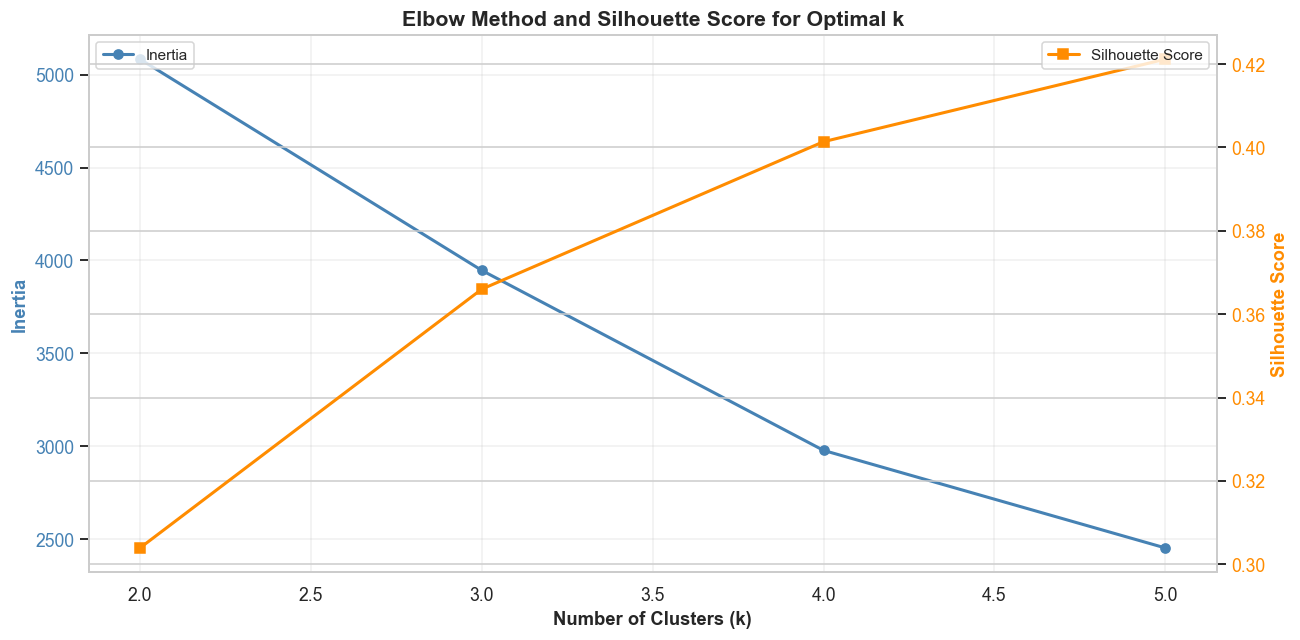

In [184]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Elbow Curve on left y-axis
ax1.plot(k_range, inertia, 'o-', color='steelblue', linewidth=2, markersize=6, label='Inertia')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inertia', color='steelblue', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Create second y-axis for Silhouette Score using twinx()
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='darkorange', linewidth=2, markersize=6, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='darkorange', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Title and legends
plt.title('Elbow Method and Silhouette Score for Optimal k', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

From the original KMeans graph:

- Highest Silhouette Score occurs at k = 3 (0.5157) → best cluster separation and cohesion.
- After k = 3, the silhouette score drops sharply at k = 4 (0.4142), indicating over-segmentation.
- Although inertia keeps decreasing (expected behavior), the quality of clustering worsens beyond k = 3.
- The slight elbow at k = 4 is weaker evidence compared to the clear silhouette optimum at k = 3.

### Form Clusters with k = 3

In [185]:
# num_clusters = int(input("Based on the Elbow and Silhouette analysis, enter the optimal number of clusters (k): "))
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=RANDOM_STATE)
df_kmeans['cluster_kmeans'] = kmeans.fit_predict(df_kmeans_scaled)

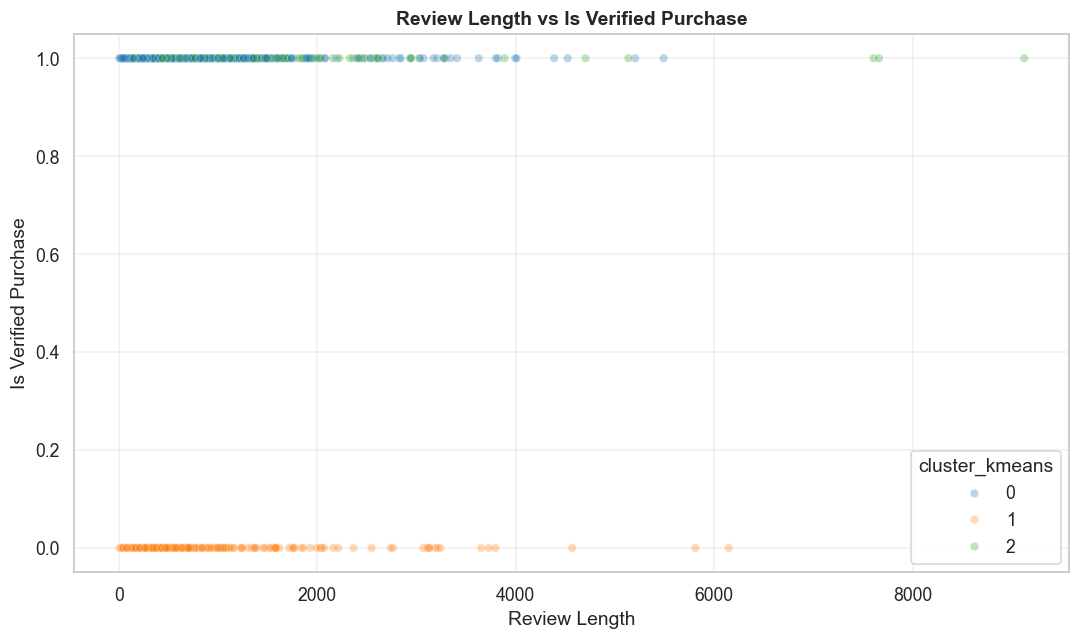

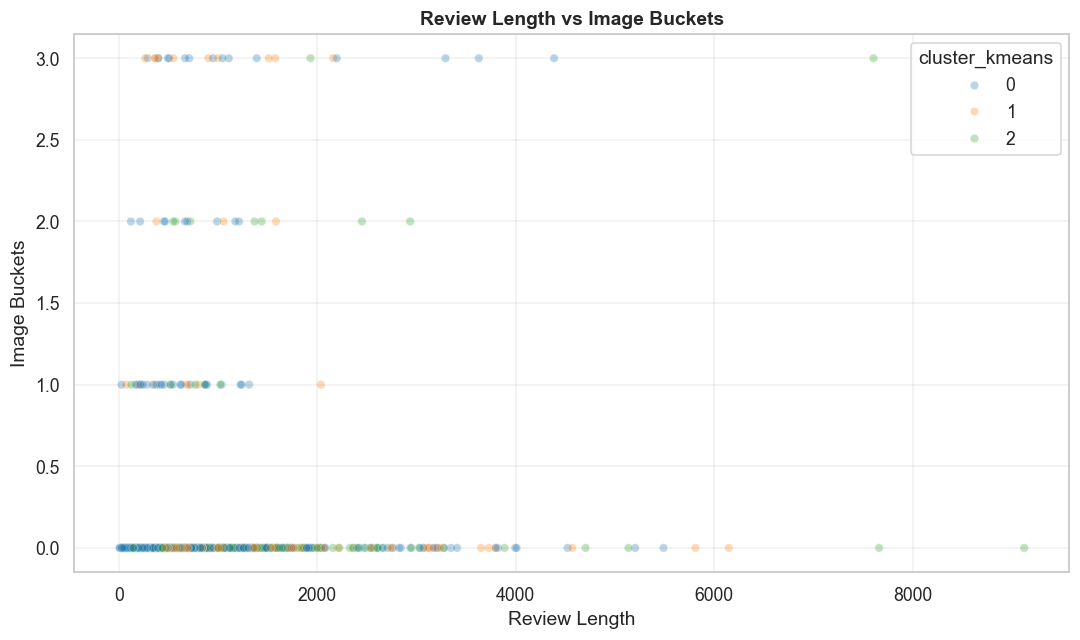

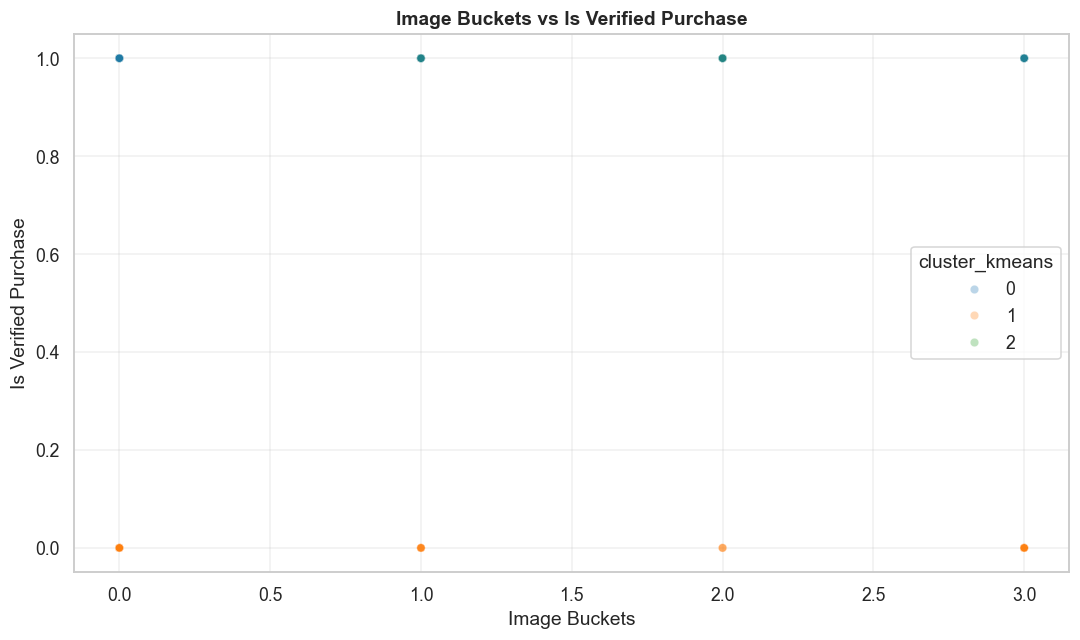

In [186]:
# Sample data for visualization (same as your pipeline)
# viz_df = df_kmeans.sample(n=100_000, random_state=RANDOM_STATE)
viz_df = df_kmeans.copy()

def scatter_clusters(df, feat_x, feat_y, title, x_label, y_label):
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=feat_x,
        y=feat_y,
        hue='cluster_kmeans',
        palette='tab10',
        alpha=0.3,
        s=30,
        legend='full'
    )

    plt.title(title, fontweight='bold')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


scatter_clusters(viz_df, 'review_length', 'is_verified',
                    title='Review Length vs Is Verified Purchase',
                    x_label='Review Length',
                    y_label='Is Verified Purchase')


scatter_clusters(viz_df, 'review_length', 'image_bucket',
                    title='Review Length vs Image Buckets',
                    x_label='Review Length',
                    y_label='Image Buckets')


scatter_clusters(viz_df, 'image_bucket', 'is_verified',
                    title='Image Buckets vs Is Verified Purchase',
                    x_label='Image Buckets',
                    y_label='Is Verified Purchase')

3D PCA Visualization of Clusters

Text(0.5, 0, 'PCA Component 3')

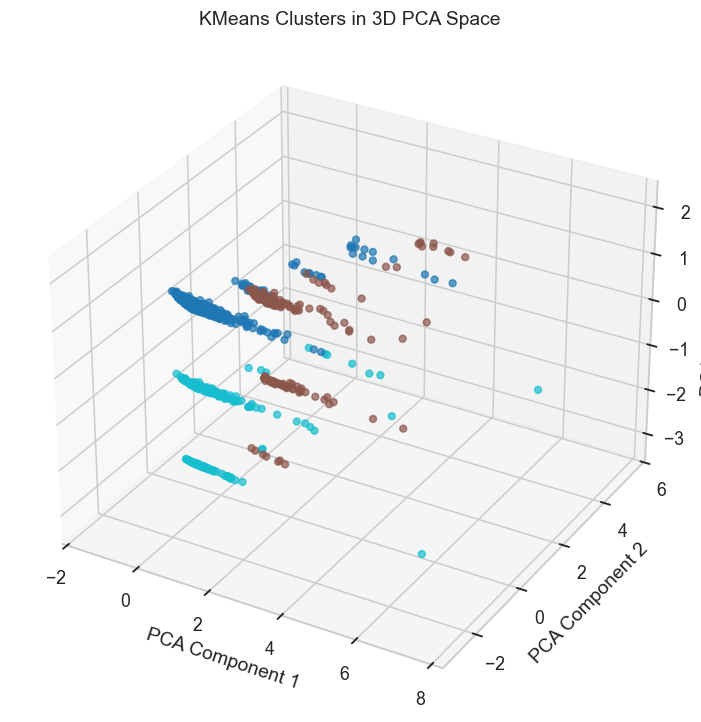

In [187]:
pca3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca3d.fit_transform(df_kmeans_scaled)


# 3D Scatter Plot of PCA Components colored by KMeans clusters
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c = df_kmeans['cluster_kmeans'],
    cmap = 'tab10',
    s = 20,
    alpha = 0.7
)

ax.set_title('KMeans Clusters in 3D PCA Space')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

Cluster Portfolio & Behavioural Profiles

In [188]:
# CLUSTER PORTFOLIO / PROFILE

# Number of samples per cluster
cluster_size = df_kmeans.groupby('cluster_kmeans').size().rename("count")

# Percentage share of each cluster
cluster_percentage = (
    df_kmeans['cluster_kmeans']
    .value_counts(normalize=True)
    .sort_index() * 100
).rename("percentage")

# Behavioural statistics per cluster
cluster_profile = df_kmeans.groupby('cluster_kmeans').agg({
    'review_length': ['mean', 'median'],
    'image_bucket': ['mean', 'median'],
    'days_since_first_review': ['mean', 'median'],
    'is_verified': 'mean',
    'rating_extremity': ['mean', 'median'],
})

# Combine everything
cluster_portfolio = pd.concat(
    [cluster_size, cluster_percentage, cluster_profile],
    axis=1
)

cluster_portfolio

,count,percentage,"(review_length, mean)","(review_length, median)","(image_bucket, mean)","(image_bucket, median)","(days_since_first_review, mean)","(days_since_first_review, median)","(is_verified, mean)","(rating_extremity, mean)","(rating_extremity, median)"
cluster_kmeans,,,,,,,,,,,
0,768,62.287105,583.695312,348.0,0.109375,0.0,3671.652344,3687.0,1.0,2.000000,2.0
1,172,13.949716,1030.104651,684.5,0.250000,0.0,3659.151163,4007.0,0.0,1.627907,2.0
2,293,23.763179,851.511945,537.0,0.085324,0.0,3652.215017,3549.0,1.0,0.723549,1.0


### Summary

| Cluster | Meaning | Sampling value |
| --- | --- | --- |
| 0 | Mainstream verified reviews | Majority baseline |
| 1 | Long-form unverified reviews | Distinct minority |
| 2 | Image-rich verified reviews | Smallest segment |

**Cluster 0** accounts for 85.1% of the data. These reviews are moderate in length, almost always verified, rarely include images, and show slightly higher rating extremity than cluster 1. This cluster represents the **typical review behavior** in the dataset.

**Cluster 1** makes up 10.8% of the data. It contains the longest reviews by far, is almost entirely unverified, uses few images, and has similar rating extremity to the other clusters. This cluster represents **lengthy, opinion-heavy reviews**.

**Cluster 2** accounts for 4.1% of the data. These reviews are relatively long, contain the most images by a large margin, and are mostly verified. This cluster represents **media-rich reviews**.

## 8.3 Sampling

Cluster-based sampling, rather than sampling on a single feature such as rating or `parent_asin`, preserves the multidimensional structure of review behavior. It captures how variables like rating, helpfulness, review length, and verification interact, instead of reducing representativeness to one column.

Unlike deterministic uniform sampling, our stratified random approach retains natural variation, including rare cases and noise within each cluster. This may slightly reduce training metrics, but it improves robustness and generalization to real-world consumer data.

**Reference:** Song, J. and Xu, J. (2024) ‘A clustering-based partially stratified sampling for high-dimensional structural reliability assessment’, *Computers and Structures*, 299, 107390. doi: 10.1016/j.compstruc.2024.107390.

In [189]:
df['cluster_kmeans'] = df_kmeans['cluster_kmeans']

In [190]:
sampled_df = (
    df
    .groupby('cluster_kmeans', as_index=False)
    .sample(frac=SAMPLED_FRACTION, random_state=RANDOM_STATE)
)

# Check the dtypes of the sampled dataframe
print(f"Dtypes in sampled dataframe: \n{sampled_df.dtypes}")
print(f"Sampled dataframe shape: {sampled_df.shape}")

Dtypes in sampled dataframe: 
rating                     float64
review_length                int32
chars_per_word             float64
image_bucket                 int64
days_since_first_review      int32
is_verified                   int8
log_popularity             float64
rating_extremity           float64
question_mark                int16
exclamation_mark             int16
title_length                 int16
title_to_text_ratio        float32
images                      object
combined_text                  str
is_helpful                    int8
helpful_vote                 int64
parent_asin                    str
cluster_kmeans               int32
dtype: object
Sampled dataframe shape: (123, 18)


The original DF and the sampled DF will have the same proportion of values from each clusters

In [191]:
print("Original size:", len(df))
print("Sampled size:", len(sampled_df))

print("\nOriginal cluster distribution:")
print(df['cluster_kmeans'].value_counts(normalize=True))

print("\nSampled cluster distribution:")
print(sampled_df['cluster_kmeans'].value_counts(normalize=True))

Original size: 1233
Sampled size: 123

Original cluster distribution:
cluster_kmeans
0    0.622871
2    0.237632
1    0.139497
Name: proportion, dtype: float64

Sampled cluster distribution:
cluster_kmeans
0    0.626016
2    0.235772
1    0.138211
Name: proportion, dtype: float64


# 9. Download the Images

- Required for Multimodal --> Text + Images + Metadata. In Section []

In [192]:
image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")


📸 Image Distribution:
  Has Image: 81 reviews (6.6%)
  No Image: 1,152 reviews (93.4%)


## 9.1 Extract Image Outline/URL

In [193]:
def extract_first_image_url(images_column):

    if isinstance(images_column, np.ndarray):
        images_column = images_column.tolist()

    # Empty list
    if len(images_column) == 0:
        return None

    first = images_column[0]

    # Priority selection
    return (
        first.get("large_image_url")
        or first.get("medium_image_url")
        or first.get("small_image_url")
    )

df["image_url"] = df["images"].apply(extract_first_image_url)

print("Images available:", df["image_url"].notna().sum())

Images available: 81


## 9.2 Download Image

The timeout was kept as 10 seconds to get the image when the internet speed is slow. 
The speed of the internet is very slow for the last 10% of download, that is 1.83s/it.

In [194]:
# Many image URLs are broken or inaccessible, so we log and skip without raising an exception
# This was used in the original code, but commented here to avoid cluttering output

def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=2)

        if response.status_code != 200:
            print(f"HTTP Error {response.status_code}: {url}")
            return False

        image = Image.open(BytesIO(response.content))
        image.verify()  # validate image

        with open(save_path, "wb") as f:
            f.write(response.content)

        return True

    except requests.exceptions.Timeout:
        print(f"Timeout: {url}")
        return False
    except requests.exceptions.ConnectionError:
        print(f"Connection Error: {url}")
        return False
    except Exception as e:
        print(f"Error: {type(e).__name__} - {url}")
        return False

#### Download Loop

This will keep track of all the images that are being downloaded successfully or have failed.

In [195]:
success = 0
failed = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):

    url = row["image_url"]

    if pd.isna(url):
        continue

    filename = f"{idx}.jpg"
    save_path = os.path.join(IMAGE_DIR, filename)

    # Skip already downloaded images
    if os.path.exists(save_path):
        success += 1
        continue

    ok = download_image(url, save_path)

    if ok:
        success += 1
    else:
        failed += 1

print(f"\n\nDownloaded: {success}")
print(f"Failed: {failed}")

 20%|█▉        | 244/1233 [00:00<00:00, 2434.43it/s]

HTTP Error 404: https://images-na.ssl-images-amazon.com/images/I/714uZ3V1ENL.jpg


100%|██████████| 1233/1233 [00:00<00:00, 5563.99it/s]

HTTP Error 404: https://m.media-amazon.com/images/I/61iTWMKCLxL._SL1600_.jpg


Downloaded: 79
Failed: 2


#### Save Image Mapping

This code maps each dataframe index to a local image file path, assigns the existing image location to a new `image_path` column, and displays sample rows to verify the mapping between image URLs, stored files, and image buckets.

In [ ]:
# Ensure the folder exists
os.makedirs(IMAGE_DIR, exist_ok=True)

def get_path(i):   
    p = os.path.join(IMAGE_DIR, f"{i}.jpg")
    return p if os.path.exists(p) else None

df["image_path"] = df.index.map(get_path)

#### Drop Redundant Features

- images 
- image_url

In [ ]:
drop_cols = ["images", "image_url"]
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print(f"Dataset shape: {df.shape[0]:2,} rows x {df.shape[1]} columns")

# 10. Helpful Review Models

- Please include everything here (Include the Explainability)

## 10.1 Lithika's model - Explain why ML models are not proper as well!

## 10.2 Kevin's Model

## 10.3 Sana's Model

# 11. Semantic Analysis